# Line list analyser

This script constructs and analyses rovibrational quadrupole line lists for N₂ isotopologues by combining Duo/ExoMol outputs with HITRAN data. The script performs quantum-number matching between datasets, filters transitions, computes summary statistics (e.g. number of lines per band), and generates key figures including stick spectra, temperature-dependent broadened spectra, and partition functions.

In [1]:
import re
import numpy as np
import pandas as pd
from decimal import Decimal
from pathlib import Path
from IPython.display import display

# ============================================================
# User settings
# ============================================================

STRICT_HITRAN_MATCH = True  # if True, raise an error if any HITRAN lines are left unmatched
STICK_MATCH_TOL = 1e-4      # cm^-1

# Updated .states file output
SAVE_UPDATED_STATES_FILES = True
UPDATED_STATES_SUFFIX = "_with_uncertainties.states"
UPDATED_STATES_UNC_FORMAT = ".6f"

ISOTOPOLOGUES = {
    "14N2": {
        "states_path": "Duo/14N2/14N2_v80_J80.states",
        "trans_path":  "Duo/14N2/14N2_v80_J80.trans",
        "par_path":    "HITRAN/linelists/14N2_Q.par",
        "stick_path": "ExoCross/stick_spectra/14N2_v80_J80.stick",
    },
    "14N15N": {
        "states_path": "Duo/14N15N/14N15N_v80_J80.states",
        "trans_path":  "Duo/14N15N/14N15N_v80_J80.trans",
        "par_path":    "HITRAN/linelists/14N15N_Q.par",
        "stick_path": "ExoCross/stick_spectra/14N15N_v80_J80.stick",
    },
    "15N2": {
        "states_path": "Duo/15N2/15N2_v80_J80.states",
        "trans_path":  "Duo/15N2/15N2_v80_J80.trans",
        "par_path":    None,  # no HITRAN data
        "stick_path": "ExoCross/stick_spectra/15N2_v80_J80.stick",
    },
}

QN_KEY = ["v_u", "v_l", "J_u", "J_l"]

MATCHED_DISPLAY_COLS = [
    "v_u", "v_l", "J_u", "J_l",
    "nu_hitran", "nu_exomol",
    "S_hitran", "A_exomol", "S_exomol",
    "unc_upper", "unc_lower", "transition_uncertainty",
    "nu_diff", "abs_nu_diff",
]

ALL_EXOMOL_DISPLAY_COLS = [
    "v_u", "v_l", "J_u", "J_l",
    "nu_exomol", "A_exomol",
    "S_exomol",
    "unc_upper", "unc_lower", "transition_uncertainty",
    "matched_to_hitran",
    "nu_hitran", "S_hitran",
    "nu_diff", "abs_nu_diff",
]

# ============================================================
# General helpers
# ============================================================

def decimal_key(token):
    """
    Parse a numeric token into an exact Decimal key.
    """
    token = str(token).strip()
    if token == "":
        raise ValueError("Empty numeric token encountered.")
    return Decimal(token)


def duplicate_key_rows(df, key_cols):
    return df[df.duplicated(key_cols, keep=False)].copy()


def assert_unique_quantum_number_key(df, key_cols, dataset_name, extra_sort_cols=None):
    """
    Matching is required to be ONLY by quantum number.
    Therefore the quantum-number key must be unique in each dataset.
    """
    dup = duplicate_key_rows(df, key_cols)
    if dup.empty:
        return

    sort_cols = key_cols.copy()
    if extra_sort_cols:
        sort_cols += [c for c in extra_sort_cols if c not in sort_cols]

    print(f"\nDuplicate quantum-number keys found in {dataset_name}:")
    display(dup.sort_values(sort_cols).head(50))

    raise ValueError(
        f"{dataset_name} contains duplicated rows for the key {key_cols}. "
        "Matching by quantum number only is therefore ambiguous."
    )

# ============================================================
# Uncertainty model
# ============================================================

def level_uncertainty_n2(v, J):
    """
    Empirical energy-level uncertainty model, applied to all isotopologues.

    Implemented exactly as specified:

        sigma_E(v,J) = 0.002 + a*v + b*J(J+1)

    where b = 1e-5 cm^-1 and

        a = 0      for v <= 7
        a = 0.01   for 7 < v <= 19
        a = 0.02   for v > 19

    Returns sigma_E in cm^-1.
    """
    v = int(v)
    J = int(J)

    if v <= 7:
        a = 0.0
    elif v <= 19:
        a = 0.01
    else:
        a = 0.02

    b = 1e-5
    return 0.002 + a * v + b * J * (J + 1)


def attach_level_uncertainties(states_table):
    """
    Add the level energy uncertainty column to a parsed states table.
    """
    out = states_table.copy()
    out["level_uncertainty"] = [
        level_uncertainty_n2(v, J) for v, J in zip(out["v"], out["J"])
    ]
    return out


def attach_transition_uncertainties(all_exomol_table):
    """
    Compute transition uncertainty by summing upper and lower level
    uncertainties in quadrature.
    """
    out = all_exomol_table.copy()

    unc_u = pd.to_numeric(out["unc_upper"], errors="coerce")
    unc_l = pd.to_numeric(out["unc_lower"], errors="coerce")
    out["transition_uncertainty"] = np.sqrt(unc_u**2 + unc_l**2)

    return out

# ============================================================
# Updated .states file writing
# ============================================================

def build_updated_states_output_path(states_path, suffix=UPDATED_STATES_SUFFIX):
    """
    Build an output path by appending a suffix to the stem of the original file.
    Example:
        foo.states -> foo_with_uncertainties.states
    """
    p = Path(states_path)
    return p.with_name(f"{p.stem}{suffix}")


def write_states_file_with_uncertainties(
    input_states_path,
    output_states_path,
    states_table_with_uncertainties,
    uncertainty_format=UPDATED_STATES_UNC_FORMAT,
):
    """
    Write an updated .states file by APPENDING the level uncertainty as a new
    final column to each data line, while preserving the original file content
    exactly otherwise.

    Blank lines and comment lines are copied unchanged.
    Data lines are copied exactly, with the uncertainty appended at the end.
    """
    sigma_map = states_table_with_uncertainties.set_index("state_id")["level_uncertainty"].to_dict()

    input_path = Path(input_states_path)
    output_path = Path(output_states_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with input_path.open("r", encoding="utf-8") as fin, output_path.open("w", encoding="utf-8") as fout:
        for line_number, line in enumerate(fin, start=1):
            stripped = line.strip()

            # Preserve blank lines and comment lines exactly
            if stripped == "" or stripped.startswith("#"):
                fout.write(line)
                continue

            # Parse the state_id from the original data line
            tokens = stripped.split()
            try:
                state_id = int(tokens[0])
            except Exception as exc:
                raise ValueError(
                    f"Could not parse state_id from line {line_number} of {input_states_path}"
                ) from exc

            if state_id not in sigma_map:
                raise KeyError(
                    f"state_id {state_id} from line {line_number} of {input_states_path} "
                    f"not found in states_table_with_uncertainties."
                )

            sigma = sigma_map[state_id]
            sigma_str = format(float(sigma), uncertainty_format)

            # Preserve original content exactly, only append the new column
            fout.write(line.rstrip("\n") + f" {sigma_str}\n")

    return str(output_path)

# ============================================================
# HITRAN parsing
# ============================================================

def parse_hitran_vib_n2(line):
    """
    HITRAN Class 1a global quanta parsing for N2.
    Uses fixed-width fields:
      upper global quanta: columns 67–81 -> line[67:82]
      lower global quanta: columns 82–96 -> line[82:97]
    """
    global_u = line[67:82]
    global_l = line[82:97]

    v_u = int(global_u.strip()) if global_u.strip() else None
    v_l = int(global_l.strip()) if global_l.strip() else None
    return v_u, v_l


def parse_hitran_rot_n2(line):
    """
    Parse J_u and J_l from the HITRAN local quanta fields.

    For N2 quadrupole lines, the branch/J information is typically encoded
    in the local quanta fields as something like 'S  3q'.
    In practice this is usually found in the lower local quantum field.
    """
    local_u = line[97:112].strip()
    local_l = line[112:127].strip()

    m = re.match(r"^([OPQRS])\s*(\d+)", local_l)
    if m:
        local_label = local_l
    else:
        m = re.match(r"^([OPQRS])\s*(\d+)", local_u)
        if m:
            local_label = local_u
        else:
            return None, None, None, None

    branch = m.group(1)
    J_l = int(m.group(2))
    dJ_map = {"O": -2, "P": -1, "Q": 0, "R": 1, "S": 2}
    dJ = dJ_map[branch]
    J_u = J_l + dJ

    if J_u < 0:
        return None, None, None, None

    return J_u, J_l, branch, local_label


def parse_hitran_par_n2(par_path):
    """
    Parse a HITRAN .par file into a minimal dataframe.

    Output columns:
      hitran_id, par_line_number,
      v_u, v_l, J_u, J_l,
      nu_hitran, S_hitran,
      branch, hitran_local_label
    """
    rows = []

    with open(par_path, "r") as f:
        for par_line_number, line in enumerate(f, start=1):
            if not line.strip():
                continue

            try:
                nu_hitran = float(line[3:15])
                S_hitran = float(line[15:25])
            except ValueError:
                continue

            v_u, v_l = parse_hitran_vib_n2(line)
            if v_u is None or v_l is None:
                continue

            J_u, J_l, branch, hitran_local_label = parse_hitran_rot_n2(line)
            if J_u is None or J_l is None:
                continue

            rows.append({
                "par_line_number": par_line_number,
                "v_u": v_u,
                "v_l": v_l,
                "J_u": J_u,
                "J_l": J_l,
                "nu_hitran": nu_hitran,
                "S_hitran": S_hitran,
                "branch": branch,
                "hitran_local_label": hitran_local_label,
            })

    df = pd.DataFrame(rows)

    if df.empty:
        return pd.DataFrame(columns=[
            "hitran_id", "par_line_number",
            "v_u", "v_l", "J_u", "J_l",
            "nu_hitran", "S_hitran",
            "branch", "hitran_local_label"
        ])

    df.insert(0, "hitran_id", np.arange(1, len(df) + 1))
    return df

# ============================================================
# ExoMol / Duo parsing
# ============================================================

def parse_exomol_states(states_path):
    """
    Parse the first 8 columns of a Duo/ExoMol .states file.

    Expected columns:
      0: state_id
      1: E
      2: g
      3: J
      4: parity
      5: ef
      6: label
      7: v

    Level uncertainties are computed immediately and stored as
    'level_uncertainty'.
    """
    states = pd.read_csv(
        states_path,
        sep=r"\s+",
        comment="#",
        header=None,
        usecols=range(8),
        names=["state_id", "E", "g", "J", "parity", "ef", "label", "v"],
        engine="python",
    )

    states["state_id"] = states["state_id"].astype(int)
    states["J"] = pd.to_numeric(states["J"], errors="raise").astype(int)
    states["v"] = pd.to_numeric(states["v"], errors="raise").astype(int)
    states["label"] = states["label"].astype(str)

    states = attach_level_uncertainties(states)

    return states[["state_id", "v", "J", "parity", "ef", "label", "level_uncertainty"]]


def parse_exomol_trans(trans_path):
    """
    Parse the first 4 columns of a Duo/ExoMol .trans file.

    Expected columns:
      0: upper_id
      1: lower_id
      2: A_exomol
      3: nu_exomol

    Keeps an exact Decimal key for robust stick matching.
    """
    raw = pd.read_csv(
        trans_path,
        sep=r"\s+",
        comment="#",
        header=None,
        usecols=range(4),
        names=["upper_id", "lower_id", "A_exomol", "nu_exomol"],
        dtype=str,
        engine="python",
    )

    raw["upper_id"] = raw["upper_id"].astype(int)
    raw["lower_id"] = raw["lower_id"].astype(int)
    raw["A_exomol"] = pd.to_numeric(raw["A_exomol"], errors="raise")
    raw["nu_exomol_key"] = raw["nu_exomol"].map(decimal_key)
    raw["nu_exomol"] = pd.to_numeric(raw["nu_exomol"], errors="raise")

    raw.insert(0, "exomol_trans_id", np.arange(1, len(raw) + 1))
    return raw


def build_exomol_transition_table(states_path, trans_path):
    """
    Build the ExoMol transition table with quantum numbers attached.

    Keeps internal columns:
      upper_id, lower_id,
      label_u, label_l,
      parity_u, ef_u, parity_l, ef_l,
      nu_exomol_key

    Also stores:
      unc_upper, unc_lower, transition_uncertainty
    """
    states = parse_exomol_states(states_path)
    trans = parse_exomol_trans(trans_path)

    upper_states = states.rename(columns={
        "state_id": "upper_id",
        "v": "v_u",
        "J": "J_u",
        "parity": "parity_u",
        "ef": "ef_u",
        "label": "label_u",
        "level_uncertainty": "unc_upper",
    })

    lower_states = states.rename(columns={
        "state_id": "lower_id",
        "v": "v_l",
        "J": "J_l",
        "parity": "parity_l",
        "ef": "ef_l",
        "label": "label_l",
        "level_uncertainty": "unc_lower",
    })

    df = (
        trans
        .merge(
            upper_states[["upper_id", "v_u", "J_u", "parity_u", "ef_u", "label_u", "unc_upper"]],
            on="upper_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            lower_states[["lower_id", "v_l", "J_l", "parity_l", "ef_l", "label_l", "unc_lower"]],
            on="lower_id",
            how="left",
            validate="many_to_one",
        )
    )

    if df[["v_u", "v_l", "J_u", "J_l"]].isna().any().any():
        raise ValueError("Some transitions could not be joined to the states file.")

    df["S_exomol"] = pd.NA
    df = attach_transition_uncertainties(df)

    return states, df[[
        "exomol_trans_id",
        "v_u", "v_l", "J_u", "J_l",
        "nu_exomol_key", "nu_exomol",
        "A_exomol", "S_exomol",
        "unc_upper", "unc_lower", "transition_uncertainty",
        "upper_id", "lower_id",
        "label_u", "label_l",
        "parity_u", "ef_u", "parity_l", "ef_l",
    ]]

# ============================================================
# ExoMol line intensity parsing from stick files
# ============================================================

def parse_exomol_stick(stick_path):
    """
    Parse a two-column ExoCross stick file:
        nu_exomol   S_exomol
    """
    stick = pd.read_csv(
        stick_path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["nu_exomol_str", "S_exomol_str"],
        dtype=str,
        engine="python",
    ).dropna(how="any")

    if stick.empty:
        raise ValueError(f"Stick file is empty: {stick_path}")

    stick.insert(0, "stick_row_id", np.arange(1, len(stick) + 1))
    stick["nu_exomol_key"] = stick["nu_exomol_str"].map(decimal_key)
    stick["nu_exomol_stick"] = stick["nu_exomol_str"].astype(float)
    stick["S_exomol"] = pd.to_numeric(stick["S_exomol_str"], errors="raise")

    return stick[["stick_row_id", "nu_exomol_key", "nu_exomol_stick", "S_exomol"]]


def attach_exomol_stick_intensities(all_exomol_table, stick_path, tol=1e-3):
    """
    Attach S_exomol from an ExoCross stick file.

    Matching rule:
      - sort ExoMol transitions and stick rows by wavenumber
      - require equal row counts
      - require row-by-row agreement within an absolute tolerance `tol`
      - then assign S_exomol row-by-row
    """
    out = all_exomol_table.copy()
    stick = parse_exomol_stick(stick_path)

    if len(out) != len(stick):
        raise AssertionError(
            f"Stick file line count does not match ExoMol line count: "
            f"{len(stick)} (stick) vs {len(out)} (ExoMol)."
        )

    exo_sorted = (
        out.reset_index(names="_original_index")
           .sort_values(["nu_exomol", "exomol_trans_id"], kind="stable")
           .reset_index(drop=True)
    )

    stk_sorted = (
        stick.sort_values(["nu_exomol_stick", "stick_row_id"], kind="stable")
             .reset_index(drop=True)
    )

    abs_diff = np.abs(
        exo_sorted["nu_exomol"].to_numpy() - stk_sorted["nu_exomol_stick"].to_numpy()
    )

    bad = abs_diff > tol

    if bad.any():
        cmp = pd.DataFrame({
            "sorted_row": np.arange(1, len(exo_sorted) + 1),
            "nu_exomol": exo_sorted["nu_exomol"].to_numpy(),
            "nu_stick": stk_sorted["nu_exomol_stick"].to_numpy(),
            "abs_diff": abs_diff,
        })

        print(f"\nFirst rows where |nu_exomol - nu_stick| > {tol}:")
        display(cmp[bad].head(20))

        raise AssertionError(
            f"Stick intensities could not be attached: "
            f"ExoMol and stick wavenumbers do not match row-by-row within {tol} cm^-1."
        )

    exo_sorted["nu_stick"] = stk_sorted["nu_exomol_stick"].to_numpy()
    exo_sorted["abs_stick_nu_diff"] = abs_diff
    exo_sorted["S_exomol"] = stk_sorted["S_exomol"].to_numpy()

    restored = (
        exo_sorted.sort_values("_original_index", kind="stable")
                  .drop(columns=["_original_index"])
                  .reset_index(drop=True)
    )

    if restored["S_exomol"].isna().any():
        raise AssertionError("Some ExoMol rows still have missing S_exomol after stick matching.")

    return restored

# ============================================================
# Main isotopologue processing
# ============================================================

def process_isotopologue(
    name,
    states_path,
    trans_path,
    par_path=None,
    stick_path=None,
    strict_hitran_match=True,
    save_updated_states_files=False,
):
    """
    Build:
      - states_table: parsed states with level uncertainties
      - matched_table: only lines matched to HITRAN
      - all_exomol_table: one row per ExoMol transition
      - unmatched_exomol_table
      - unmatched_hitran_table
      - raw hitran / exomol tables
      - summary dict

    Also optionally writes an updated .states file with level uncertainty
    appended as an extra final column.
    """
    states_table, exomol = build_exomol_transition_table(states_path, trans_path)

    updated_states_output_path = None
    if save_updated_states_files:
        updated_states_output_path = build_updated_states_output_path(states_path)
        write_states_file_with_uncertainties(
            input_states_path=states_path,
            output_states_path=updated_states_output_path,
            states_table_with_uncertainties=states_table,
            uncertainty_format=UPDATED_STATES_UNC_FORMAT,
        )

    # Attach S_exomol first, so it propagates to all derived tables
    if stick_path is not None:
        exomol = attach_exomol_stick_intensities(
            exomol,
            stick_path,
            tol=STICK_MATCH_TOL,
        )
        if exomol["S_exomol"].isna().any():
            raise AssertionError(f"{name}: some ExoMol lines still have missing S_exomol after stick matching.")

    # Start the full ExoMol table now; HITRAN columns will be added if available.
    all_exomol = exomol.copy()
    for col in ["hitran_id", "nu_hitran", "S_hitran", "branch", "hitran_local_label", "nu_diff", "abs_nu_diff"]:
        all_exomol[col] = pd.NA
    all_exomol["matched_to_hitran"] = False

    if par_path is None:
        matched_table = all_exomol.iloc[0:0].copy()
        unmatched_exomol = all_exomol.copy()
        unmatched_hitran = pd.DataFrame(columns=[
            "hitran_id", "par_line_number",
            "v_u", "v_l", "J_u", "J_l",
            "nu_hitran", "S_hitran",
            "branch", "hitran_local_label"
        ])

        summary = {
            "isotopologue": name,
            "n_states": len(states_table),
            "n_exomol_lines": len(exomol),
            "n_hitran_lines": 0,
            "n_hitran_matched": 0,
            "n_hitran_unmatched": 0,
            "n_exomol_unmatched": len(unmatched_exomol),
            "updated_states_output_path": updated_states_output_path,
        }

        return {
            "states_table": states_table.sort_values(["v", "J", "state_id"]).reset_index(drop=True),
            "updated_states_output_path": updated_states_output_path,
            "matched_table": matched_table.sort_values(["v_l", "v_u", "J_l", "J_u", "nu_exomol"]).reset_index(drop=True),
            "all_exomol_table": all_exomol.sort_values(["v_l", "v_u", "J_l", "J_u", "nu_exomol"]).reset_index(drop=True),
            "unmatched_exomol_table": unmatched_exomol.sort_values(["v_l", "v_u", "J_l", "J_u", "nu_exomol"]).reset_index(drop=True),
            "unmatched_hitran_table": unmatched_hitran,
            "hitran_table": unmatched_hitran.copy(),
            "exomol_table": exomol.sort_values(["v_l", "v_u", "J_l", "J_u", "nu_exomol"]).reset_index(drop=True),
            "summary": summary,
        }

    hitran = parse_hitran_par_n2(par_path)

    assert_unique_quantum_number_key(
        hitran, QN_KEY, f"{name} HITRAN",
        extra_sort_cols=["nu_hitran", "S_hitran", "hitran_id"]
    )
    assert_unique_quantum_number_key(
        exomol, QN_KEY, f"{name} ExoMol",
        extra_sort_cols=["nu_exomol", "A_exomol", "exomol_trans_id"]
    )

    # Strict one-to-one match on quantum numbers only
    matched_meta = exomol.merge(
        hitran[["hitran_id", "v_u", "v_l", "J_u", "J_l", "nu_hitran", "S_hitran", "branch", "hitran_local_label"]],
        on=QN_KEY,
        how="inner",
        validate="one_to_one",
    )

    matched_meta["nu_diff"] = matched_meta["nu_exomol"] - matched_meta["nu_hitran"]
    matched_meta["abs_nu_diff"] = matched_meta["nu_diff"].abs()

    # Attach HITRAN info back onto the full ExoMol table
    all_exomol = all_exomol.drop(
        columns=["hitran_id", "nu_hitran", "S_hitran", "branch", "hitran_local_label", "nu_diff", "abs_nu_diff"]
    )
    all_exomol = all_exomol.merge(
        matched_meta[[
            "exomol_trans_id",
            "hitran_id", "nu_hitran", "S_hitran",
            "branch", "hitran_local_label",
            "nu_diff", "abs_nu_diff"
        ]],
        on="exomol_trans_id",
        how="left",
        validate="one_to_one",
    )
    all_exomol["matched_to_hitran"] = all_exomol["hitran_id"].notna()

    matched_table = all_exomol[all_exomol["matched_to_hitran"]].copy()
    unmatched_exomol = all_exomol[~all_exomol["matched_to_hitran"]].copy()

    unmatched_hitran = hitran[~hitran["hitran_id"].isin(matched_meta["hitran_id"])].copy()

    n_hitran_matched = matched_meta["hitran_id"].nunique()
    n_hitran_unmatched = len(unmatched_hitran)

    if strict_hitran_match and n_hitran_unmatched != 0:
        print(f"\n{name}: unmatched HITRAN lines found:")
        display(unmatched_hitran.sort_values(["v_l", "v_u", "J_l", "J_u", "nu_hitran"]).head(50))
        raise AssertionError(f"{name}: {n_hitran_unmatched} HITRAN lines were not matched.")

    summary = {
        "isotopologue": name,
        "n_states": len(states_table),
        "n_exomol_lines": len(exomol),
        "n_hitran_lines": len(hitran),
        "n_hitran_matched": n_hitran_matched,
        "n_hitran_unmatched": n_hitran_unmatched,
        "n_exomol_unmatched": len(unmatched_exomol),
        "updated_states_output_path": updated_states_output_path,
    }

    sort_cols = ["v_l", "v_u", "J_l", "J_u", "nu_exomol"]

    return {
        "states_table": states_table.sort_values(["v", "J", "state_id"]).reset_index(drop=True),
        "updated_states_output_path": updated_states_output_path,
        "matched_table": matched_table.sort_values(sort_cols).reset_index(drop=True),
        "all_exomol_table": all_exomol.sort_values(sort_cols).reset_index(drop=True),
        "unmatched_exomol_table": unmatched_exomol.sort_values(sort_cols).reset_index(drop=True),
        "unmatched_hitran_table": unmatched_hitran.sort_values(["v_l", "v_u", "J_l", "J_u", "nu_hitran"]).reset_index(drop=True),
        "hitran_table": hitran.sort_values(["v_l", "v_u", "J_l", "J_u", "nu_hitran"]).reset_index(drop=True),
        "exomol_table": exomol.sort_values(sort_cols).reset_index(drop=True),
        "summary": summary,
    }

# ============================================================
# Run for all isotopologues
# ============================================================

results = {}
states_tables = {}
matched_tables = {}
all_exomol_tables = {}
unmatched_exomol_tables = {}
unmatched_hitran_tables = {}
summary_rows = []

for iso, cfg in ISOTOPOLOGUES.items():
    res = process_isotopologue(
        iso,
        states_path=cfg["states_path"],
        trans_path=cfg["trans_path"],
        par_path=cfg["par_path"],
        stick_path=cfg.get("stick_path"),
        strict_hitran_match=STRICT_HITRAN_MATCH,
        save_updated_states_files=SAVE_UPDATED_STATES_FILES,
    )

    results[iso] = res
    states_tables[iso] = res["states_table"]
    matched_tables[iso] = res["matched_table"]
    all_exomol_tables[iso] = res["all_exomol_table"]
    unmatched_exomol_tables[iso] = res["unmatched_exomol_table"]
    unmatched_hitran_tables[iso] = res["unmatched_hitran_table"]
    summary_rows.append(res["summary"])

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

# ------------------------------------------------------------
# Default notebook displays
# ------------------------------------------------------------

for iso in ISOTOPOLOGUES:
    print(f"\n{'='*80}")
    print(iso)
    print(f"{'='*80}")

    print("\nCounts:")
    print(summary_df[summary_df["isotopologue"] == iso].to_string(index=False))

    if results[iso]["updated_states_output_path"] is not None:
        print(f"\nUpdated .states file written to:\n{results[iso]['updated_states_output_path']}")

    print("\nMatched table:")
    if matched_tables[iso].empty:
        print("(empty)")
    else:
        display(matched_tables[iso][MATCHED_DISPLAY_COLS].head(50))

    print("\nAll ExoMol table:")
    display(all_exomol_tables[iso][ALL_EXOMOL_DISPLAY_COLS].head(50))

    print("\nStates table with level uncertainties:")
    display(states_tables[iso][["state_id", "v", "J", "level_uncertainty"]].head(20))

,isotopologue,n_states,n_exomol_lines,n_hitran_lines,n_hitran_matched,n_hitran_unmatched,n_exomol_unmatched,updated_states_output_path
0,14N2,6561,30462,1107,1107,0,29355,Duo/14N2/14N2_v80_J80_with_uncertainties.states
1,14N15N,6561,30620,161,161,0,30459,Duo/14N15N/14N15N_v80_J80_with_uncertainties.s...
2,15N2,6561,31541,0,0,0,31541,Duo/15N2/15N2_v80_J80_with_uncertainties.states



14N2

Counts:
isotopologue  n_states  n_exomol_lines  n_hitran_lines  n_hitran_matched  n_hitran_unmatched  n_exomol_unmatched                      updated_states_output_path
        14N2      6561           30462            1107              1107                   0               29355 Duo/14N2/14N2_v80_J80_with_uncertainties.states

Updated .states file written to:
Duo/14N2/14N2_v80_J80_with_uncertainties.states

Matched table:


,v_u,v_l,J_u,J_l,nu_hitran,nu_exomol,S_hitran,A_exomol,S_exomol,unc_upper,unc_lower,transition_uncertainty,nu_diff,abs_nu_diff
0,0,0,2,0,11.937345,11.937345,2.286000e-34,6.812200e-18,2.280366e-34,0.00206,0.00200,0.002871,0.000000e+00,0.000000e+00
1,0,0,3,1,19.895115,19.895115,1.527000e-33,1.126200e-16,1.523705e-33,0.00212,0.00202,0.002928,0.000000e+00,0.000000e+00
2,0,0,4,2,27.852196,27.852196,1.582000e-32,6.728200e-16,1.578374e-32,0.00220,0.00206,0.003014,0.000000e+00,0.000000e+00
3,0,0,5,3,35.808313,35.808313,2.594000e-32,2.506300e-15,2.587974e-32,0.00230,0.00212,0.003128,0.000000e+00,0.000000e+00
4,0,0,6,4,43.763189,43.763189,1.290000e-31,7.096000e-15,1.287281e-31,0.00242,0.00220,0.003271,0.000000e+00,0.000000e+00
5,0,0,7,5,51.716550,51.716550,1.328000e-31,1.678800e-14,1.324926e-31,0.00256,0.00230,0.003441,0.000000e+00,0.000000e+00
6,0,0,8,6,59.668120,59.668120,4.754000e-31,3.498800e-14,4.742226e-31,0.00272,0.00242,0.003641,0.000000e+00,0.000000e+00
7,0,0,9,7,67.617623,67.617623,3.813000e-31,6.636200e-14,3.803623e-31,0.00290,0.00256,0.003868,0.000000e+00,0.000000e+00
8,0,0,10,8,75.564784,75.564784,1.119000e-30,1.170200e-13,1.116082e-30,0.00310,0.00272,0.004124,0.000000e+00,0.000000e+00
9,0,0,11,9,83.509328,83.509328,7.614000e-31,1.947300e-13,7.594877e-31,0.00332,0.00290,0.004408,0.000000e+00,0.000000e+00



All ExoMol table:


,v_u,v_l,J_u,J_l,nu_exomol,A_exomol,S_exomol,unc_upper,unc_lower,transition_uncertainty,matched_to_hitran,nu_hitran,S_hitran,nu_diff,abs_nu_diff
0,0,0,2,0,11.937345,6.812200e-18,2.280366e-34,0.00206,0.00200,0.002871,True,11.937345,2.286000e-34,0.000000e+00,0.000000e+00
1,0,0,3,1,19.895115,1.126200e-16,1.523705e-33,0.00212,0.00202,0.002928,True,19.895115,1.527000e-33,0.000000e+00,0.000000e+00
2,0,0,4,2,27.852196,6.728200e-16,1.578374e-32,0.00220,0.00206,0.003014,True,27.852196,1.582000e-32,0.000000e+00,0.000000e+00
3,0,0,5,3,35.808313,2.506300e-15,2.587974e-32,0.00230,0.00212,0.003128,True,35.808313,2.594000e-32,0.000000e+00,0.000000e+00
4,0,0,6,4,43.763189,7.096000e-15,1.287281e-31,0.00242,0.00220,0.003271,True,43.763189,1.290000e-31,0.000000e+00,0.000000e+00
5,0,0,7,5,51.716550,1.678800e-14,1.324926e-31,0.00256,0.00230,0.003441,True,51.716550,1.328000e-31,0.000000e+00,0.000000e+00
6,0,0,8,6,59.668120,3.498800e-14,4.742226e-31,0.00272,0.00242,0.003641,True,59.668120,4.754000e-31,0.000000e+00,0.000000e+00
7,0,0,9,7,67.617623,6.636200e-14,3.803623e-31,0.00290,0.00256,0.003868,True,67.617623,3.813000e-31,0.000000e+00,0.000000e+00
8,0,0,10,8,75.564784,1.170200e-13,1.116082e-30,0.00310,0.00272,0.004124,True,75.564784,1.119000e-30,0.000000e+00,0.000000e+00
9,0,0,11,9,83.509328,1.947300e-13,7.594877e-31,0.00332,0.00290,0.004408,True,83.509328,7.614000e-31,0.000000e+00,0.000000e+00


...

,state_id,v,J,level_uncertainty
0,1,0,0,0.00200
1,82,0,1,0.00202
2,163,0,2,0.00206
3,244,0,3,0.00212
4,325,0,4,0.00220
5,406,0,5,0.00230
6,487,0,6,0.00242
7,568,0,7,0.00256
8,649,0,8,0.00272
9,730,0,9,0.00290



15N2

Counts:
isotopologue  n_states  n_exomol_lines  n_hitran_lines  n_hitran_matched  n_hitran_unmatched  n_exomol_unmatched                      updated_states_output_path
        15N2      6561           31541               0                 0                   0               31541 Duo/15N2/15N2_v80_J80_with_uncertainties.states

Updated .states file written to:
Duo/15N2/15N2_v80_J80_with_uncertainties.states

Matched table:
(empty)

All ExoMol table:


,v_u,v_l,J_u,J_l,nu_exomol,A_exomol,S_exomol,unc_upper,unc_lower,transition_uncertainty,matched_to_hitran,nu_hitran,S_hitran,nu_diff,abs_nu_diff
0,0,0,2,0,11.145455,4.835300e-18,8.221527e-41,0.00206,0.00200,0.002871,False,<NA>,<NA>,<NA>,<NA>
1,0,0,3,1,18.575358,7.993600e-17,3.304386e-39,0.00212,0.00202,0.002928,False,<NA>,<NA>,<NA>,<NA>
2,0,0,4,2,26.004660,4.775800e-16,5.726886e-39,0.00220,0.00206,0.003014,False,<NA>,<NA>,<NA>,<NA>
3,0,0,5,3,33.433122,1.779100e-15,5.662904e-38,0.00230,0.00212,0.003128,False,<NA>,<NA>,<NA>,<NA>
4,0,0,6,4,40.860503,5.037100e-15,4.724436e-38,0.00242,0.00220,0.003271,False,<NA>,<NA>,<NA>,<NA>
5,0,0,7,5,48.286564,1.191700e-14,2.939808e-37,0.00256,0.00230,0.003441,False,<NA>,<NA>,<NA>,<NA>
6,0,0,8,6,55.711063,2.483800e-14,1.769439e-37,0.00272,0.00242,0.003641,False,<NA>,<NA>,<NA>,<NA>
7,0,0,9,7,63.133761,4.711200e-14,8.602274e-37,0.00290,0.00256,0.003868,False,<NA>,<NA>,<NA>,<NA>
8,0,0,10,8,70.554419,8.308300e-14,4.255456e-37,0.00310,0.00272,0.004124,False,<NA>,<NA>,<NA>,<NA>
9,0,0,11,9,77.972795,1.382600e-13,1.759654e-36,0.00332,0.00290,0.004408,False,<NA>,<NA>,<NA>,<NA>



States table with level uncertainties:


,state_id,v,J,level_uncertainty
0,1,0,0,0.00200
1,82,0,1,0.00202
2,163,0,2,0.00206
3,244,0,3,0.00212
4,325,0,4,0.00220
5,406,0,5,0.00230
6,487,0,6,0.00242
7,568,0,7,0.00256
8,649,0,8,0.00272
9,730,0,9,0.00290


### Initial Statistics

In [2]:
# make copy of table and sort table by size of nu difference (descending order)
matched_tables["14N2"].sort_values("abs_nu_diff", ascending=False).head(10)
matched_tables["14N15N"].sort_values("abs_nu_diff", ascending=False).head(20)

# extract full nu difference array, sorted by size of nu difference (descending order)
nu_diff_14N2 = matched_tables["14N2"]["nu_diff"].abs().sort_values(ascending=False).values
nu_diff_14N15N = matched_tables["14N15N"]["nu_diff"].abs().sort_values(ascending=False).values

matched_tables["14N15N"].sort_values("abs_nu_diff", ascending=False).head(42)


,exomol_trans_id,v_u,v_l,J_u,J_l,nu_exomol_key,nu_exomol,A_exomol,S_exomol,unc_upper,...,nu_stick,abs_stick_nu_diff,matched_to_hitran,hitran_id,nu_hitran,S_hitran,branch,hitran_local_label,nu_diff,abs_nu_diff
160,25824,1,0,42,40,2577.742603,2577.742603,2.106000e-08,5.710583e-36,0.02006,...,2577.74260,3.000000e-06,True,161.0,2577.745537,5.710000e-36,S,S 40q,-0.002934,0.002934
157,25419,1,0,41,39,2571.653709,2571.653709,2.065600e-08,1.153303e-35,0.01922,...,2571.65371,9.999999e-07,True,160.0,2571.656641,1.153000e-35,S,S 39q,-0.002932,0.002932
154,25007,1,0,40,38,2565.521232,2565.521232,2.025600e-08,2.285511e-35,0.01840,...,2565.52123,2.000000e-06,True,159.0,2565.524161,2.286000e-35,S,S 38q,-0.002929,0.002929
151,24593,1,0,39,37,2559.345435,2559.345435,1.986100e-08,4.444240e-35,0.01760,...,2559.34544,5.000000e-06,True,158.0,2559.348360,4.444000e-35,S,S 37q,-0.002925,0.002925
148,24166,1,0,38,36,2553.126580,2553.126580,1.947100e-08,8.479337e-35,0.01682,...,2553.12658,0.000000e+00,True,157.0,2553.129501,8.482000e-35,S,S 36q,-0.002921,0.002921
145,23707,1,0,37,35,2546.864931,2546.864931,1.908500e-08,1.587190e-34,0.01606,...,2546.86493,9.999999e-07,True,156.0,2546.867847,1.587000e-34,S,S 35q,-0.002916,0.002916
142,23223,1,0,36,34,2540.560750,2540.560750,1.870300e-08,2.914551e-34,0.01532,...,2540.56075,0.000000e+00,True,155.0,2540.563660,2.914000e-34,S,S 34q,-0.002910,0.002910
139,22714,1,0,35,33,2534.214299,2534.214299,1.832600e-08,5.250314e-34,0.01460,...,2534.21430,9.999999e-07,True,154.0,2534.217202,5.250000e-34,S,S 33q,-0.002903,0.002903
136,22180,1,0,34,32,2527.825840,2527.825840,1.795400e-08,9.277738e-34,0.01390,...,2527.82584,0.000000e+00,True,153.0,2527.828736,9.278000e-34,S,S 32q,-0.002896,0.002896
133,21637,1,0,33,31,2521.395637,2521.395637,1.758600e-08,1.608007e-33,0.01322,...,2521.39564,3.000000e-06,True,152.0,2521.398525,1.608000e-33,S,S 31q,-0.002888,0.002888


In [3]:
# print maximum J_u value in the matched table
max_J_u = matched_tables["14N2"]["J_u"].max()
print(f"Maximum J_u in matched table: {max_J_u}")

# print maximum J_u value in the all ExoMol table
max_J_u_all = all_exomol_tables["14N2"]["J_u"].max()
print(f"Maximum J_u in all ExoMol table: {max_J_u_all}")
# print line from all ExoMol table with J_u = max_J_u_all
print("\nLines from all ExoMol table with maximum J_u:")
display(all_exomol_tables["14N2"][all_exomol_tables["14N2"]["J_u"] == max_J_u_all][ALL_EXOMOL_DISPLAY_COLS])


Maximum J_u in matched table: 56
Maximum J_u in all ExoMol table: 78

Lines from all ExoMol table with maximum J_u:


,v_u,v_l,J_u,J_l,nu_exomol,A_exomol,S_exomol,unc_upper,unc_lower,transition_uncertainty,matched_to_hitran,nu_hitran,S_hitran,nu_diff,abs_nu_diff
76,0,0,78,76,595.538365,3.652500e-09,1.766766e-50,0.06362,0.06052,0.087808,False,NaN,NaN,NaN,NaN
300,1,0,78,76,2818.001341,4.349800e-08,9.947331e-51,0.06362,0.06052,0.087808,False,NaN,NaN,NaN,NaN


In [4]:
# sort based on maximum percentage discrepancy in S_exomol vs S_hitran, in descending order
matched_tables["14N2"]["S_discrepancy"] = ((matched_tables["14N2"]["S_exomol"] - matched_tables["14N2"]["S_hitran"]).abs() / matched_tables["14N2"]["S_hitran"].abs()).replace([np.inf, -np.inf], np.nan)
matched_tables["14N2"].sort_values("S_discrepancy", ascending=False).head(10)

matched_tables["14N15N"]["S_discrepancy"] = ((matched_tables["14N15N"]["S_exomol"] - matched_tables["14N15N"]["S_hitran"]).abs() / matched_tables["14N15N"]["S_hitran"].abs()).replace([np.inf, -np.inf], np.nan)
matched_tables["14N15N"].sort_values("S_discrepancy", ascending=False).head(50)

,exomol_trans_id,v_u,v_l,J_u,J_l,nu_exomol_key,nu_exomol,A_exomol,S_exomol,unc_upper,...,abs_stick_nu_diff,matched_to_hitran,hitran_id,nu_hitran,S_hitran,branch,hitran_local_label,nu_diff,abs_nu_diff,S_discrepancy
62,5429,1,0,6,8,2232.954510,2232.954510,8.474400e-09,1.017144e-30,0.00242,...,0.000000e+00,True,74.0,2232.956530,1.018000e-30,O,O 8q,-0.002020,0.002020,0.000841
51,2549,1,0,4,4,2291.007500,2291.007500,6.144900e-09,7.886764e-31,0.00220,...,0.000000e+00,True,117.0,2291.009756,7.892000e-31,Q,Q 4q,-0.002256,0.002256,0.000663
33,22713,0,0,35,33,263.695545,263.695545,6.451200e-11,1.233244e-34,0.01460,...,0.000000e+00,True,34.0,263.696582,1.234000e-34,S,S 33q,-0.001037,0.001037,0.000613
153,24870,1,0,38,38,2266.847674,2266.847674,5.688100e-09,7.814543e-36,0.01682,...,4.000000e-06,True,81.0,2266.849470,7.810000e-36,Q,Q 38q,-0.001796,0.001796,0.000582
14,10519,0,0,16,14,119.103012,119.103012,1.182500e-12,1.533174e-32,0.00472,...,0.000000e+00,True,15.0,119.103485,1.534000e-32,S,S 14q,-0.000473,0.000473,0.000538
110,17043,1,0,22,24,2102.719425,2102.719425,5.053500e-09,1.715102e-32,0.00706,...,5.000000e-06,True,58.0,2102.720814,1.716000e-32,O,O 24q,-0.001389,0.001389,0.000523
113,17689,1,0,23,25,2094.339188,2094.339188,4.907300e-09,1.100439e-32,0.00752,...,2.000000e-06,True,57.0,2094.340533,1.101000e-32,O,O 25q,-0.001345,0.001345,0.000510
89,12218,1,0,15,17,2160.609953,2160.609953,6.218700e-09,2.136937e-31,0.00440,...,3.000000e-06,True,65.0,2160.611637,2.138000e-31,O,O 17q,-0.001684,0.001684,0.000497
13,9776,0,0,15,13,111.437613,111.437613,8.445200e-13,1.452291e-32,0.00440,...,1.000000e-06,True,14.0,111.438055,1.453000e-32,S,S 13q,-0.000442,0.000442,0.000488
97,14109,1,0,21,19,2441.072420,2441.072420,1.348800e-08,2.524814e-31,0.00662,...,0.000000e+00,True,140.0,2441.075159,2.526000e-31,S,S 19q,-0.002739,0.002739,0.000469


### Initial Plots

In [5]:
import matplotlib.pyplot as plt

#### Stick spectra

/tmp/ipykernel_2033569/2624218293.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.06, 0.055, 1.0, 0.89])


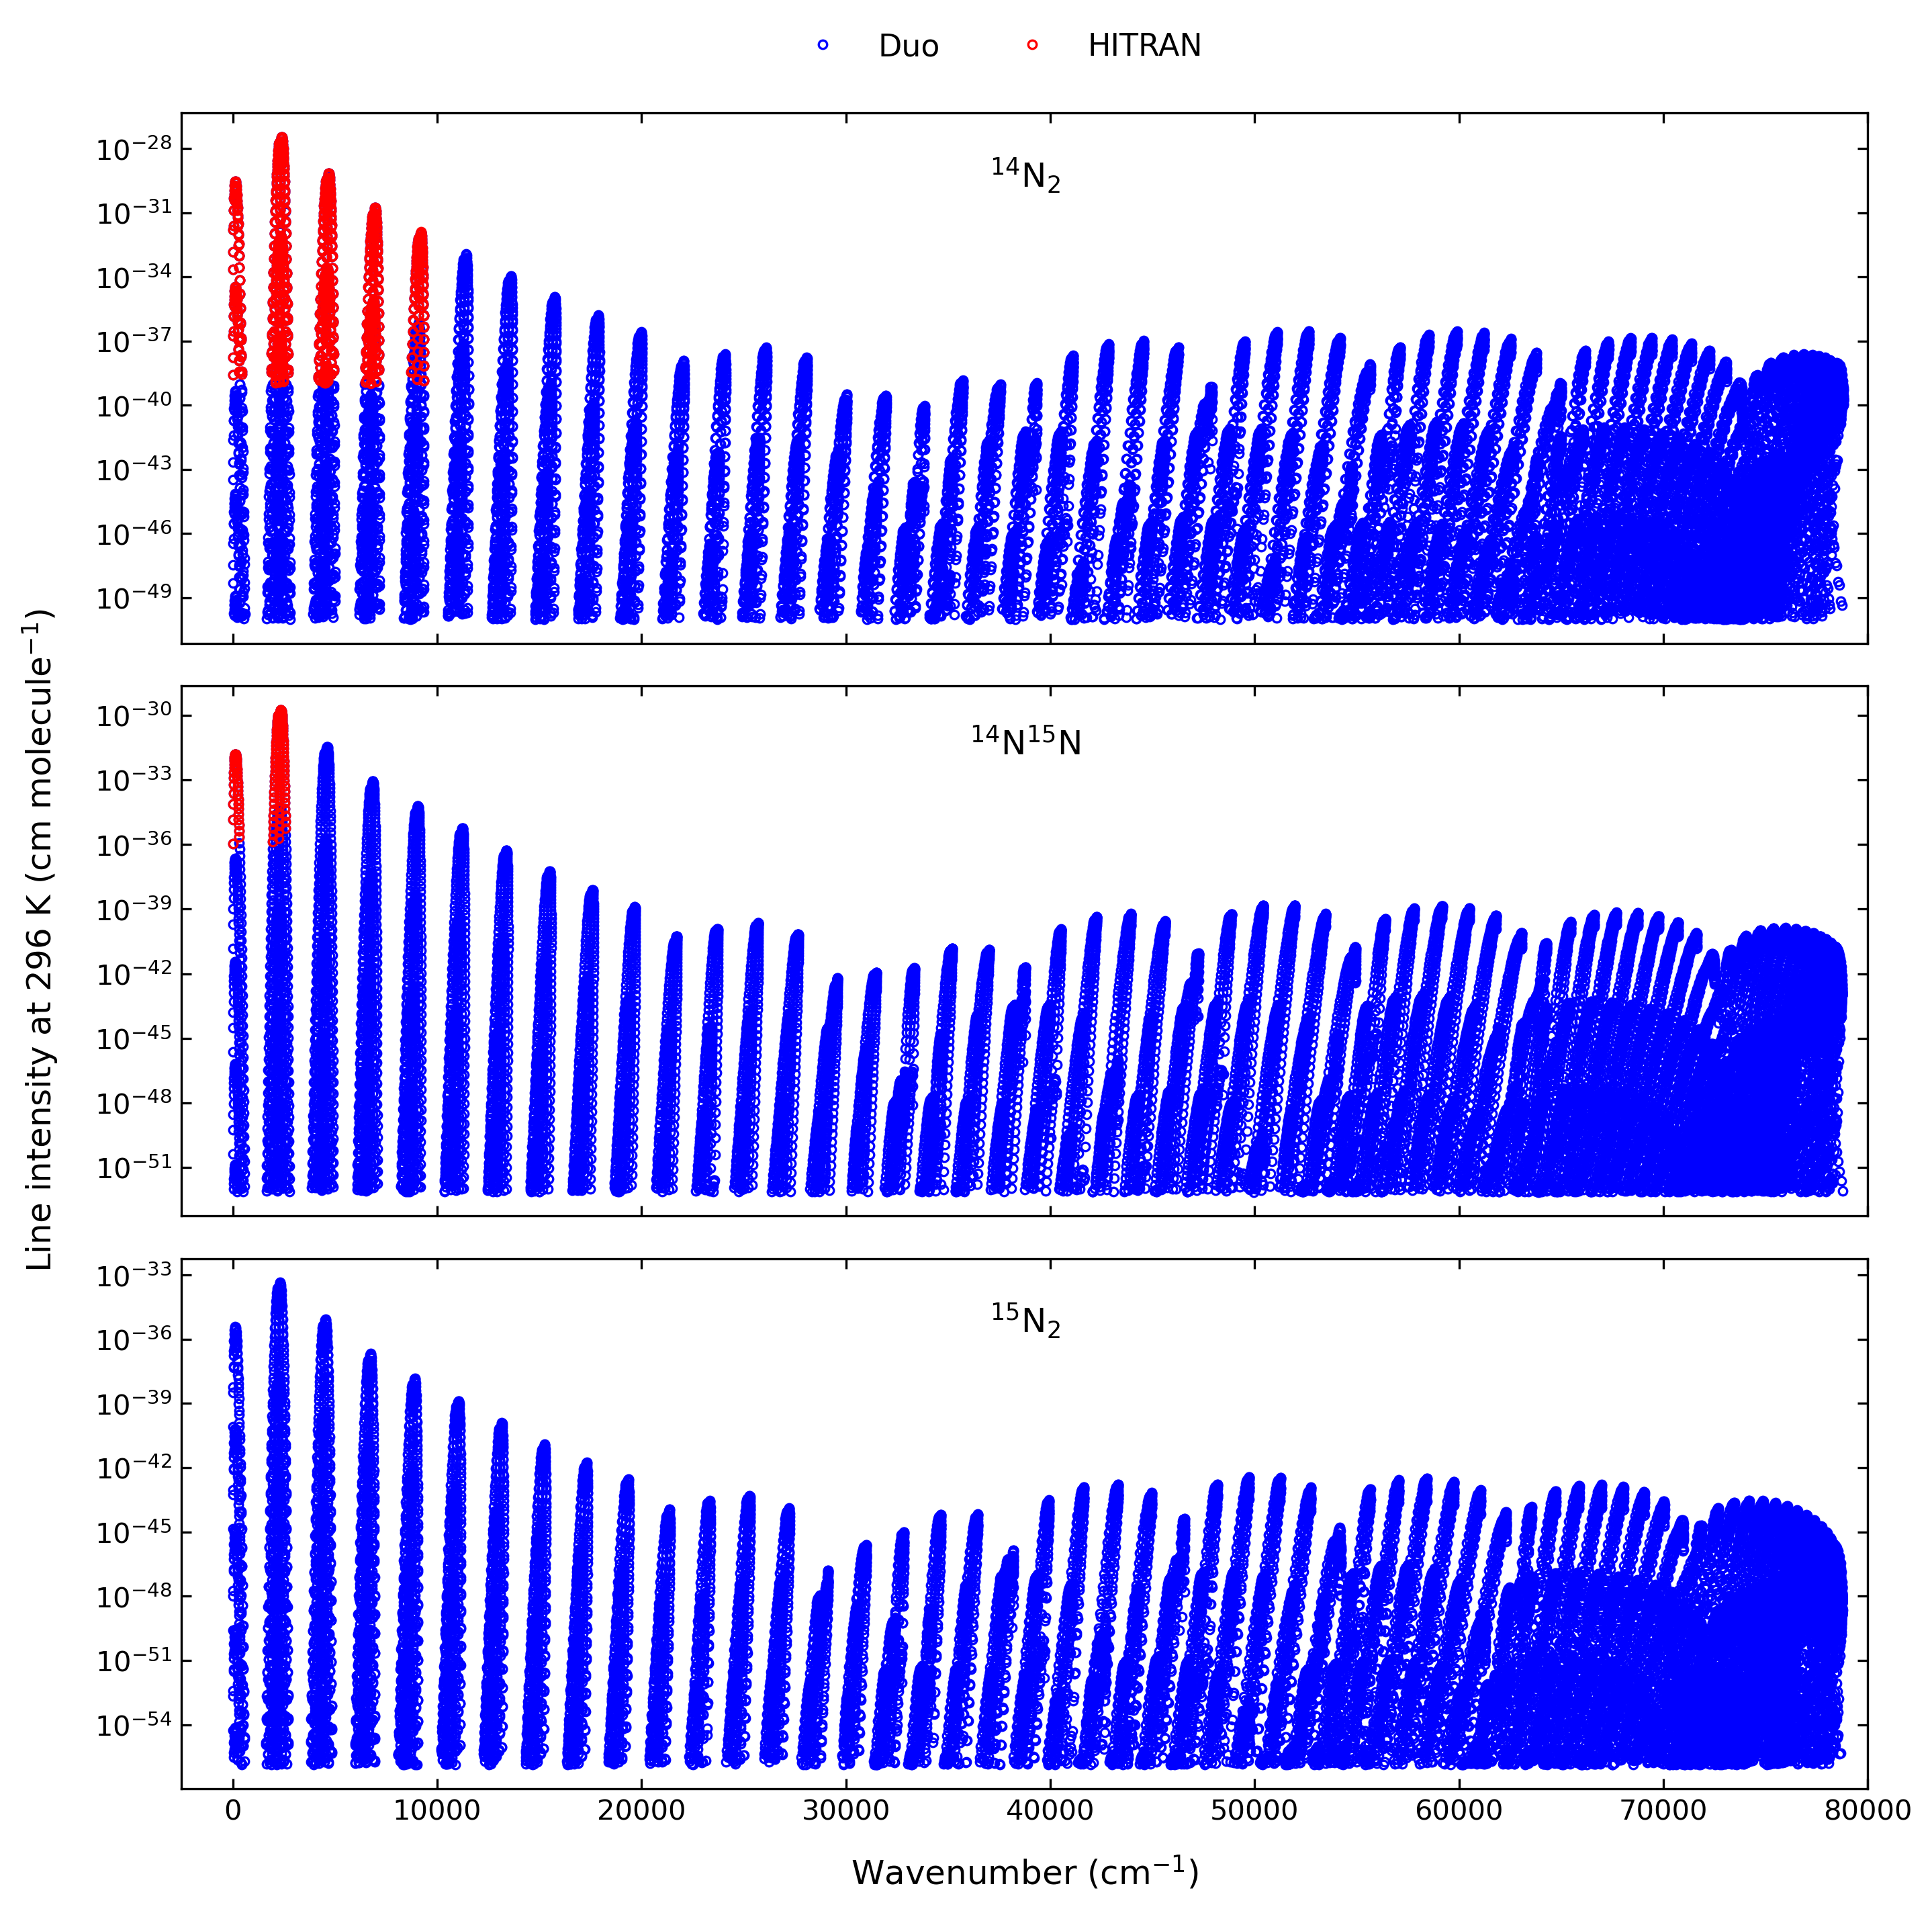

In [6]:
# ============================================================
# Combined paper-style stick spectrum plot (improved layout)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
from matplotlib.lines import Line2D

df_exomol_14N2 = all_exomol_tables["14N2"].copy()
df_hitran_14N2 = results["14N2"]["hitran_table"].copy()

df_exomol_14N15N = all_exomol_tables["14N15N"].copy()
df_hitran_14N15N = results["14N15N"]["hitran_table"].copy()

df_exomol_15N2 = all_exomol_tables["15N2"].copy()

fig, axes = plt.subplots(
    3, 1,
    figsize=(10.8, 10.8),
    dpi=300,
    sharex=True,
    gridspec_kw={"hspace": 0.08}
)

duo_color = "blue"
hitran_color = "red"

marker_size = 3.0
marker_lw = 0.8

x_min = -2500
x_max = 80000

# ------------------------------------------------------------
# 14N2
# ------------------------------------------------------------
ax = axes[0]

ax.plot(
    df_exomol_14N2["nu_exomol"],
    df_exomol_14N2["S_exomol"],
    linestyle="none",
    marker="o",
    markersize=marker_size,
    markerfacecolor="none",
    markeredgecolor=duo_color,
    markeredgewidth=marker_lw
)

ax.plot(
    df_hitran_14N2["nu_hitran"],
    df_hitran_14N2["S_hitran"],
    linestyle="none",
    marker="o",
    markersize=marker_size,
    markerfacecolor="none",
    markeredgecolor=hitran_color,
    markeredgewidth=marker_lw
)

ax.set_yscale("log")
ax.text(
    0.5, 0.92, r"$^{14}$N$_2$",
    transform=ax.transAxes,
    ha="center", va="top", fontsize=12
)

# ------------------------------------------------------------
# 14N15N
# ------------------------------------------------------------
ax = axes[1]

ax.plot(
    df_exomol_14N15N["nu_exomol"],
    df_exomol_14N15N["S_exomol"],
    linestyle="none",
    marker="o",
    markersize=marker_size,
    markerfacecolor="none",
    markeredgecolor=duo_color,
    markeredgewidth=marker_lw
)

ax.plot(
    df_hitran_14N15N["nu_hitran"],
    df_hitran_14N15N["S_hitran"],
    linestyle="none",
    marker="o",
    markersize=marker_size,
    markerfacecolor="none",
    markeredgecolor=hitran_color,
    markeredgewidth=marker_lw
)

ax.set_yscale("log")
ax.text(
    0.5, 0.92, r"$^{14}$N$^{15}$N",
    transform=ax.transAxes,
    ha="center", va="top", fontsize=12
)

# ------------------------------------------------------------
# 15N2
# ------------------------------------------------------------
ax = axes[2]

ax.plot(
    df_exomol_15N2["nu_exomol"],
    df_exomol_15N2["S_exomol"],
    linestyle="none",
    marker="o",
    markersize=marker_size,
    markerfacecolor="none",
    markeredgecolor=duo_color,
    markeredgewidth=marker_lw
)

ax.set_yscale("log")
ax.text(
    0.5, 0.92, r"$^{15}$N$_2$",
    transform=ax.transAxes,
    ha="center", va="top", fontsize=12
)

ax.set_xlabel(r"Wavenumber (cm$^{-1}$)", fontsize=12, labelpad=10)

# ------------------------------------------------------------
# Shared styling
# ------------------------------------------------------------
for ax in axes:
    ax.set_xlim(x_min, x_max)

    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())

    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax.grid(False)

# Shared y-axis label
fig.text(
    0.06, 0.5,
    r"Line intensity at 296 K (cm molecule$^{-1}$)",
    rotation=90,
    va="center", ha="center",
    fontsize=12
)

# Legend lowered to just above the top panel
handles = [
    Line2D([], [], linestyle="none", marker="o", markersize=marker_size,
           markerfacecolor="none", markeredgecolor=duo_color, markeredgewidth=marker_lw, label="Duo"),
    Line2D([], [], linestyle="none", marker="o", markersize=marker_size,
           markerfacecolor="none", markeredgecolor=hitran_color, markeredgewidth=marker_lw, label="HITRAN"),
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.93),
    fontsize=11
)

plt.tight_layout(rect=[0.06, 0.055, 1.0, 0.89])
plt.show()

Stick spectra of the unfiltered Duo quadrupole line lists, computed using rovibrational levels up to $v=80$ and $J=80$. The line lists include all transitions written by Duo, subject only to a minimum intensity threshold. HITRAN data, where available, are overlaid in red above the Duo data in blue.

### Applying filters

First, need to apply flat S_exomol cutoff at e-50, for all isotopologues

In [7]:
# ============================================================
# Simple filters:
# 1. keep only S_exomol >= 1e-45
# 2. remove transitions with v_u >= 10 or v_l >= 10
# ============================================================

MIN_S_EXOMOL = 1e-45
MAX_V = 10  # keep only v < 10

filtered_results = {}
filtered_all_exomol_tables = {}
filtered_matched_tables = {}
filtered_unmatched_exomol_tables = {}
filtered_summary_rows = []

for iso, res in results.items():
    all_df = res["all_exomol_table"].copy()
    matched_df = res["matched_table"].copy()
    unmatched_df = res["unmatched_exomol_table"].copy()

    all_df = all_df[
        (all_df["S_exomol"] >= MIN_S_EXOMOL) &
        (all_df["v_u"] < MAX_V) &
        (all_df["v_l"] < MAX_V)
    ].reset_index(drop=True)

    matched_df = matched_df[
        (matched_df["S_exomol"] >= MIN_S_EXOMOL) &
        (matched_df["v_u"] < MAX_V) &
        (matched_df["v_l"] < MAX_V)
    ].reset_index(drop=True)

    unmatched_df = unmatched_df[
        (unmatched_df["S_exomol"] >= MIN_S_EXOMOL) &
        (unmatched_df["v_u"] < MAX_V) &
        (unmatched_df["v_l"] < MAX_V)
    ].reset_index(drop=True)

    filtered_results[iso] = res.copy()
    filtered_results[iso]["all_exomol_table"] = all_df
    filtered_results[iso]["matched_table"] = matched_df
    filtered_results[iso]["unmatched_exomol_table"] = unmatched_df

    filtered_all_exomol_tables[iso] = all_df
    filtered_matched_tables[iso] = matched_df
    filtered_unmatched_exomol_tables[iso] = unmatched_df

    filtered_df = filtered_results[iso]["all_exomol_table"]

    filtered_summary_rows.append({
        "isotopologue": iso,
        "n_before": len(res["all_exomol_table"]),
        "n_after": len(all_df),
        "n_removed": len(res["all_exomol_table"]) - len(all_df),
    })

filtered_summary_df = pd.DataFrame(filtered_summary_rows)
display(filtered_summary_df)




,isotopologue,n_before,n_after,n_removed
0,14N2,30462,3705,26757
1,14N15N,30620,3070,27550
2,15N2,31541,1898,29643


/tmp/ipykernel_2033569/243263212.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.06, 0.05, 1.0, 0.94])


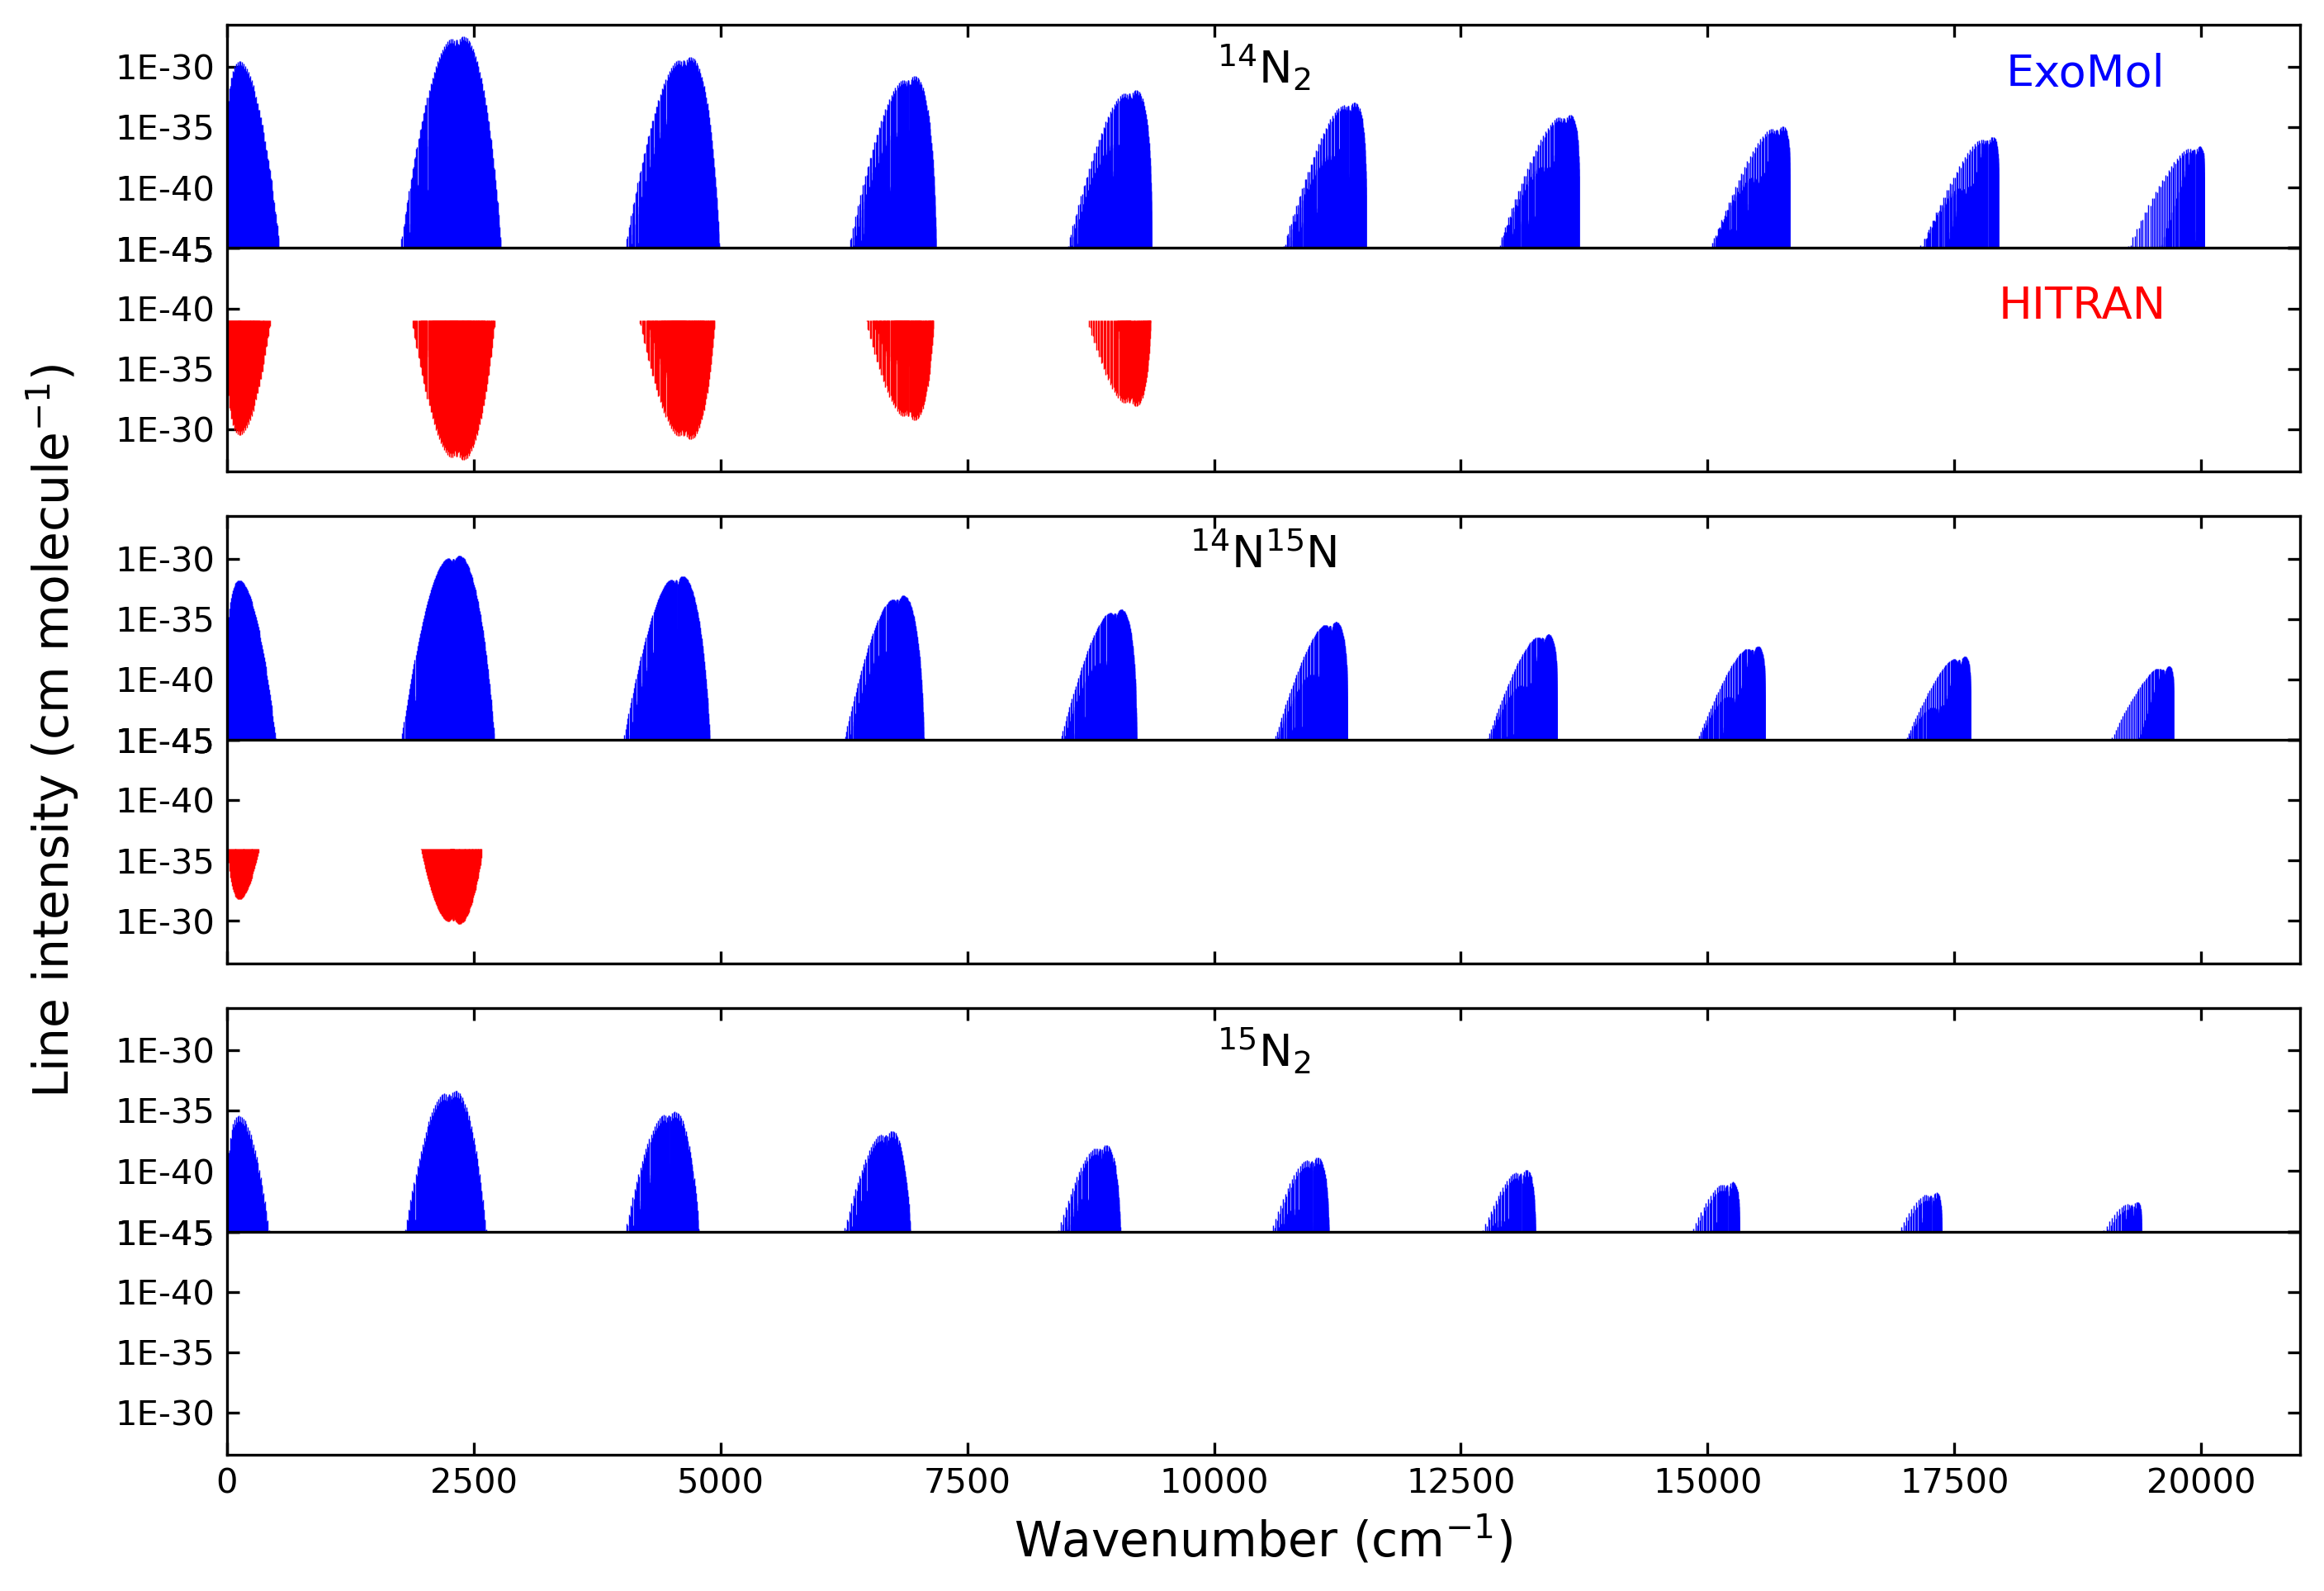

In [8]:
# ============================================================
# Mirrored stick spectrum with floating HITRAN baseline
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

df_exomol_14N2 = filtered_all_exomol_tables["14N2"].copy()
df_hitran_14N2 = results["14N2"]["hitran_table"].copy()

df_exomol_14N15N = filtered_all_exomol_tables["14N15N"].copy()
df_hitran_14N15N = results["14N15N"]["hitran_table"].copy()

df_exomol_15N2 = filtered_all_exomol_tables["15N2"].copy()

fig, axes = plt.subplots(
    3, 1,
    figsize=(10.8, 7.5),
    dpi=300,
    sharex=True,
    gridspec_kw={"hspace": 0.10}
)

duo_color = "blue"
hitran_color = "red"
stick_lw = 0.35

x_min = 0
x_max = 21000

centre_min = 1e-45
log_centre_min = np.log10(centre_min)

max_exomol = max(
    df_exomol_14N2["S_exomol"].max(),
    df_exomol_14N15N["S_exomol"].max(),
    df_exomol_15N2["S_exomol"].max(),
)
log_top_max = np.ceil(np.log10(max_exomol)) + 0.5
y_extent = log_top_max - log_centre_min

datasets = [
    (axes[0], df_exomol_14N2, df_hitran_14N2, r"$^{14}$N$_2$"),
    (axes[1], df_exomol_14N15N, df_hitran_14N15N, r"$^{14}$N$^{15}$N"),
    (axes[2], df_exomol_15N2, None, r"$^{15}$N$_2$"),
]

for ax, df_exomol, df_hitran, label in datasets:
    s_exo = df_exomol["S_exomol"].astype(float)
    y_exo = np.log10(s_exo) - log_centre_min

    ax.vlines(
        df_exomol["nu_exomol"],
        0,
        y_exo,
        color=duo_color,
        linewidth=stick_lw
    )

    if df_hitran is not None and len(df_hitran) > 0:
        s_hit = df_hitran["S_hitran"].astype(float)

        hitran_min = s_hit.min()
        hitran_offset = np.log10(hitran_min) - log_centre_min

        y_hit_top = -hitran_offset
        y_hit_bottom = -(np.log10(s_hit) - log_centre_min)

        ax.vlines(
            df_hitran["nu_hitran"],
            y_hit_top,
            y_hit_bottom,
            color=hitran_color,
            linewidth=stick_lw
        )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-y_extent, y_extent)

    ax.text(
        0.5, 0.96, label,
        transform=ax.transAxes,
        ha="center", va="top", fontsize=13
    )

    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax.grid(False)

tick_logs = np.arange(-45, int(np.ceil(log_top_max)) + 1, 5)
tick_pos = tick_logs - log_centre_min
tick_labels = [f"1E{int(t)}" for t in tick_logs]

for ax in axes:
    yticks = np.concatenate((-tick_pos[::-1], [0], tick_pos))
    ylabels = tick_labels[::-1] + [""] + tick_labels
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)

axes[-1].set_xlabel(r"Wavenumber (cm$^{-1}$)", fontsize=14)

# fig.text(0.5, 0.985, "ExoMol", ha="center", va="top", fontsize=16, color=duo_color)
# fig.text(0.5, 0.955, "HITRAN", ha="center", va="top", fontsize=16, color=hitran_color)
# fig.text(0.18, 0.92, "ExoMol", ha="left", va="top", fontsize=16, color=duo_color)
# fig.text(0.82, 0.92, "HITRAN", ha="right", va="top", fontsize=16, color=hitran_color)
fig.text(0.79, 0.865, "ExoMol", ha="left", va="top", fontsize=13, color=duo_color)
fig.text(0.85, 0.74, "HITRAN", ha="right", va="top", fontsize=13, color=hitran_color)
# fig.text(0.79, 0.595, "ExoMol", ha="left", va="top", fontsize=13, color=duo_color)
# fig.text(0.85, 0.47, "HITRAN", ha="right", va="top", fontsize=13, color=hitran_color)
# fig.text(0.79, 0.335, "ExoMol", ha="left", va="top", fontsize=13, color=duo_color)
# fig.text(0.85, 0.21, "HITRAN", ha="right", va="top", fontsize=13, color=hitran_color)

fig.text(
    0.06, 0.5,
    r"Line intensity (cm molecule$^{-1}$)",
    rotation=90,
    va="center", ha="center",
    fontsize=14
)


plt.tight_layout(rect=[0.06, 0.05, 1.0, 0.94])
plt.show()


Mirrored stick spectra comparing filtered ExoMol (above) and HITRAN (below) line intensities for the three N$_2$ isotopologues.


#### Statistics

#### filtered vs unfiltered

In [9]:
comparison_rows = [
    "Number of lines",
    r"Max wavenumber",
    r"Max $v$",
    r"Max $J$",
]

iso_labels = {
    "14N2": r"$^{14}$N$_2$",
    "14N15N": r"$^{14}$N$^{15}$N",
    "15N2": r"$^{15}$N$_2$",
}

comparison_dict = {}

for iso_key, iso_label in iso_labels.items():
    before_df = all_exomol_tables[iso_key]
    after_df = filtered_all_exomol_tables[iso_key]

    comparison_dict[(iso_label, "Before")] = [
        int(len(before_df)),
        int(round(before_df["nu_exomol"].max())),
        int(max(before_df["v_u"].max(), before_df["v_l"].max())),
        int(max(before_df["J_u"].max(), before_df["J_l"].max())),
    ]

    comparison_dict[(iso_label, "After")] = [
        int(len(after_df)),
        int(round(after_df["nu_exomol"].max())),
        int(max(after_df["v_u"].max(), after_df["v_l"].max())),
        int(max(after_df["J_u"].max(), after_df["J_l"].max())),
    ]

comparison_df = pd.DataFrame(comparison_dict, index=comparison_rows)

comparison_df.columns = pd.MultiIndex.from_tuples(
    comparison_df.columns,
    names=["Isotopologue", ""]
)

display(comparison_df)

latex_table = comparison_df.to_latex(
    multicolumn=True,
    multicolumn_format="c",
    escape=False,
    caption="Summary of ExoMol line lists before and after filtering.",
    label="tab:line_list_summary",
    column_format="l|cc|cc|cc"

)

latex_table = latex_table.replace(
    r"\begin{table}",
    r"\begin{table}" + "\n" + r"\centering"
)

print(latex_table)

Isotopologue    $^{14}$N$_2$        $^{14}$N$^{15}$N        $^{15}$N$_2$  \
                      Before  After           Before  After       Before   
Number of lines        30462   3705            30620   3070        31541   
Max wavenumber         78817  20025            78764  19711        78755   
Max $v$                   80      9               80      9           80   
Max $J$                   78     69               79     66           80   

Isotopologue            
                 After  
Number of lines   1898  
Max wavenumber   19391  
Max $v$              9  
Max $J$             59

\begin{table}
\centering
\caption{Summary of ExoMol line lists before and after filtering.}
\label{tab:line_list_summary}
\begin{tabular}{l|cc|cc|cc}
\toprule
Isotopologue & \multicolumn{2}{c}{$^{14}$N$_2$} & \multicolumn{2}{c}{$^{14}$N$^{15}$N} & \multicolumn{2}{c}{$^{15}$N$_2$} \\
 & Before & After & Before & After & Before & After \\
\midrule
Number of lines & 30462 & 3705 & 30620 & 3070 & 31541 & 1898 \\
Max wavenumber & 78817 & 20025 & 78764 & 19711 & 78755 & 19391 \\
Max $v$ & 80 & 9 & 80 & 9 & 80 & 9 \\
Max $J$ & 78 & 69 & 79 & 66 & 80 & 59 \\
\bottomrule
\end{tabular}
\end{table}



Comparison with HITRAN

In [10]:
comparison_rows = [
    "Number of lines",
    r"Max wavenumber",
    r"Max $v$",
    r"Max $J$",
]

iso_labels = {
    "14N2": r"$^{14}$N$_2$",
    "14N15N": r"$^{14}$N$^{15}$N",
    "15N2": r"$^{15}$N$_2$",
}

comparison_dict = {}

for iso_key, iso_label in iso_labels.items():
    hitran_df = results[iso_key]["hitran_table"]
    filtered_df = filtered_all_exomol_tables[iso_key]

    if len(hitran_df) > 0:
        hitran_values = [
            int(len(hitran_df)),
            int(round(hitran_df["nu_hitran"].max())),
            int(max(hitran_df["v_u"].max(), hitran_df["v_l"].max())),
            int(max(hitran_df["J_u"].max(), hitran_df["J_l"].max())),
        ]
    else:
        hitran_values = ["-", "-", "-", "-"]

    comparison_dict[(iso_label, "HITRAN")] = hitran_values
    comparison_dict[(iso_label, "Filtered ExoMol")] = [
        int(len(filtered_df)),
        int(round(filtered_df["nu_exomol"].max())),
        int(max(filtered_df["v_u"].max(), filtered_df["v_l"].max())),
        int(max(filtered_df["J_u"].max(), filtered_df["J_l"].max())),
    ]

comparison_df = pd.DataFrame(comparison_dict, index=comparison_rows)

comparison_df.columns = pd.MultiIndex.from_tuples(
    comparison_df.columns,
    names=["Isotopologue", ""]
)

display(comparison_df)

latex_table = comparison_df.to_latex(
    multicolumn=True,
    multicolumn_format="c",
    escape=False,
    caption="Comparison of HITRAN and filtered ExoMol line lists for the three N$_2$ isotopologues.",
    label="tab:hitran_exomol_comparison",
    column_format="l|cc|cc|cc"
)

latex_table = latex_table.replace(
    r"\begin{table}",
    r"\begin{table}" + "\n" + r"\centering"
)

print(latex_table)


Isotopologue    $^{14}$N$_2$                 $^{14}$N$^{15}$N                  \
                      HITRAN Filtered ExoMol           HITRAN Filtered ExoMol   
Number of lines         1107            3705              161            3070   
Max wavenumber          9354           20025             2578           19711   
Max $v$                    4               9                1               9   
Max $J$                   56              69               42              66   

Isotopologue    $^{15}$N$_2$                  
                      HITRAN Filtered ExoMol  
Number of lines            -            1898  
Max wavenumber             -           19391  
Max $v$                    -               9  
Max $J$                    -              59

\begin{table}
\centering
\caption{Comparison of HITRAN and filtered ExoMol line lists for the three N$_2$ isotopologues.}
\label{tab:hitran_exomol_comparison}
\begin{tabular}{l|cc|cc|cc}
\toprule
Isotopologue & \multicolumn{2}{c}{$^{14}$N$_2$} & \multicolumn{2}{c}{$^{14}$N$^{15}$N} & \multicolumn{2}{c}{$^{15}$N$_2$} \\
 & HITRAN & Filtered ExoMol & HITRAN & Filtered ExoMol & HITRAN & Filtered ExoMol \\
\midrule
Number of lines & 1107 & 3705 & 161 & 3070 & - & 1898 \\
Max wavenumber & 9354 & 20025 & 2578 & 19711 & - & 19391 \\
Max $v$ & 4 & 9 & 1 & 9 & - & 9 \\
Max $J$ & 56 & 69 & 42 & 66 & - & 59 \\
\bottomrule
\end{tabular}
\end{table}



### Spectra plots

In [11]:

# =========================
# FUNCTION TO LOAD XSEC
# =========================

def load_xsec(filename):
    data = np.loadtxt(filename, comments="#")
    wn = data[:, 0]        # wavenumber (cm^-1)
    xsec = data[:, 1]      # cross section (cm^2/molecule)
    return wn, xsec

# =========================
# LOAD DATA
# =========================

N214_296K_gauss_wn, N214_296K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N2_2cm_296K.xsec")
N214_50K_gauss_wn, N214_50K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N2_2cm_50K.xsec")
N214_1500K_gauss_wn, N214_1500K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N2_2cm_1500K.xsec")
N214_3000K_gauss_wn, N214_3000K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N2_2cm_3000K.xsec")

N14N15_296K_gauss_wn, N14N15_296K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N15N_2cm_296K.xsec")
N14N15_50K_gauss_wn, N14N15_50K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N15N_2cm_50K.xsec")
N14N15_1500K_gauss_wn, N14N15_1500K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N15N_2cm_1500K.xsec")
N14N15_3000K_gauss_wn, N14N15_3000K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/14N15N_2cm_3000K.xsec")

N215_296K_gauss_wn, N215_296K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/15N2_2cm_296K.xsec")
N215_50K_gauss_wn, N215_50K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/15N2_2cm_50K.xsec")
N215_1500K_gauss_wn, N215_1500K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/15N2_2cm_1500K.xsec")
N215_3000K_gauss_wn, N215_3000K_gauss_xsec = load_xsec("ExoCross/cross_sections/2cm_gaussian/15N2_2cm_3000K.xsec")

# add the cross sections for each isotopologue together to form one combined N2 cross section at each temperature
combined_296K_wn = N214_296K_gauss_wn 
combined_296K_xsec = N214_296K_gauss_xsec + N14N15_296K_gauss_xsec + N215_296K_gauss_xsec
combined_50K_wn = N214_50K_gauss_wn
combined_50K_xsec = N214_50K_gauss_xsec + N14N15_50K_gauss_xsec + N215_50K_gauss_xsec
combined_1500K_wn = N214_1500K_gauss_wn
combined_1500K_xsec = N214_1500K_gauss_xsec + N14N15_1500K_gauss_xsec + N215_1500K_gauss_xsec
combined_3000K_wn = N214_3000K_gauss_wn
combined_3000K_xsec = N214_3000K_gauss_xsec + N14N15_3000K_gauss_xsec + N215_3000K_gauss_xsec

#### wide plot

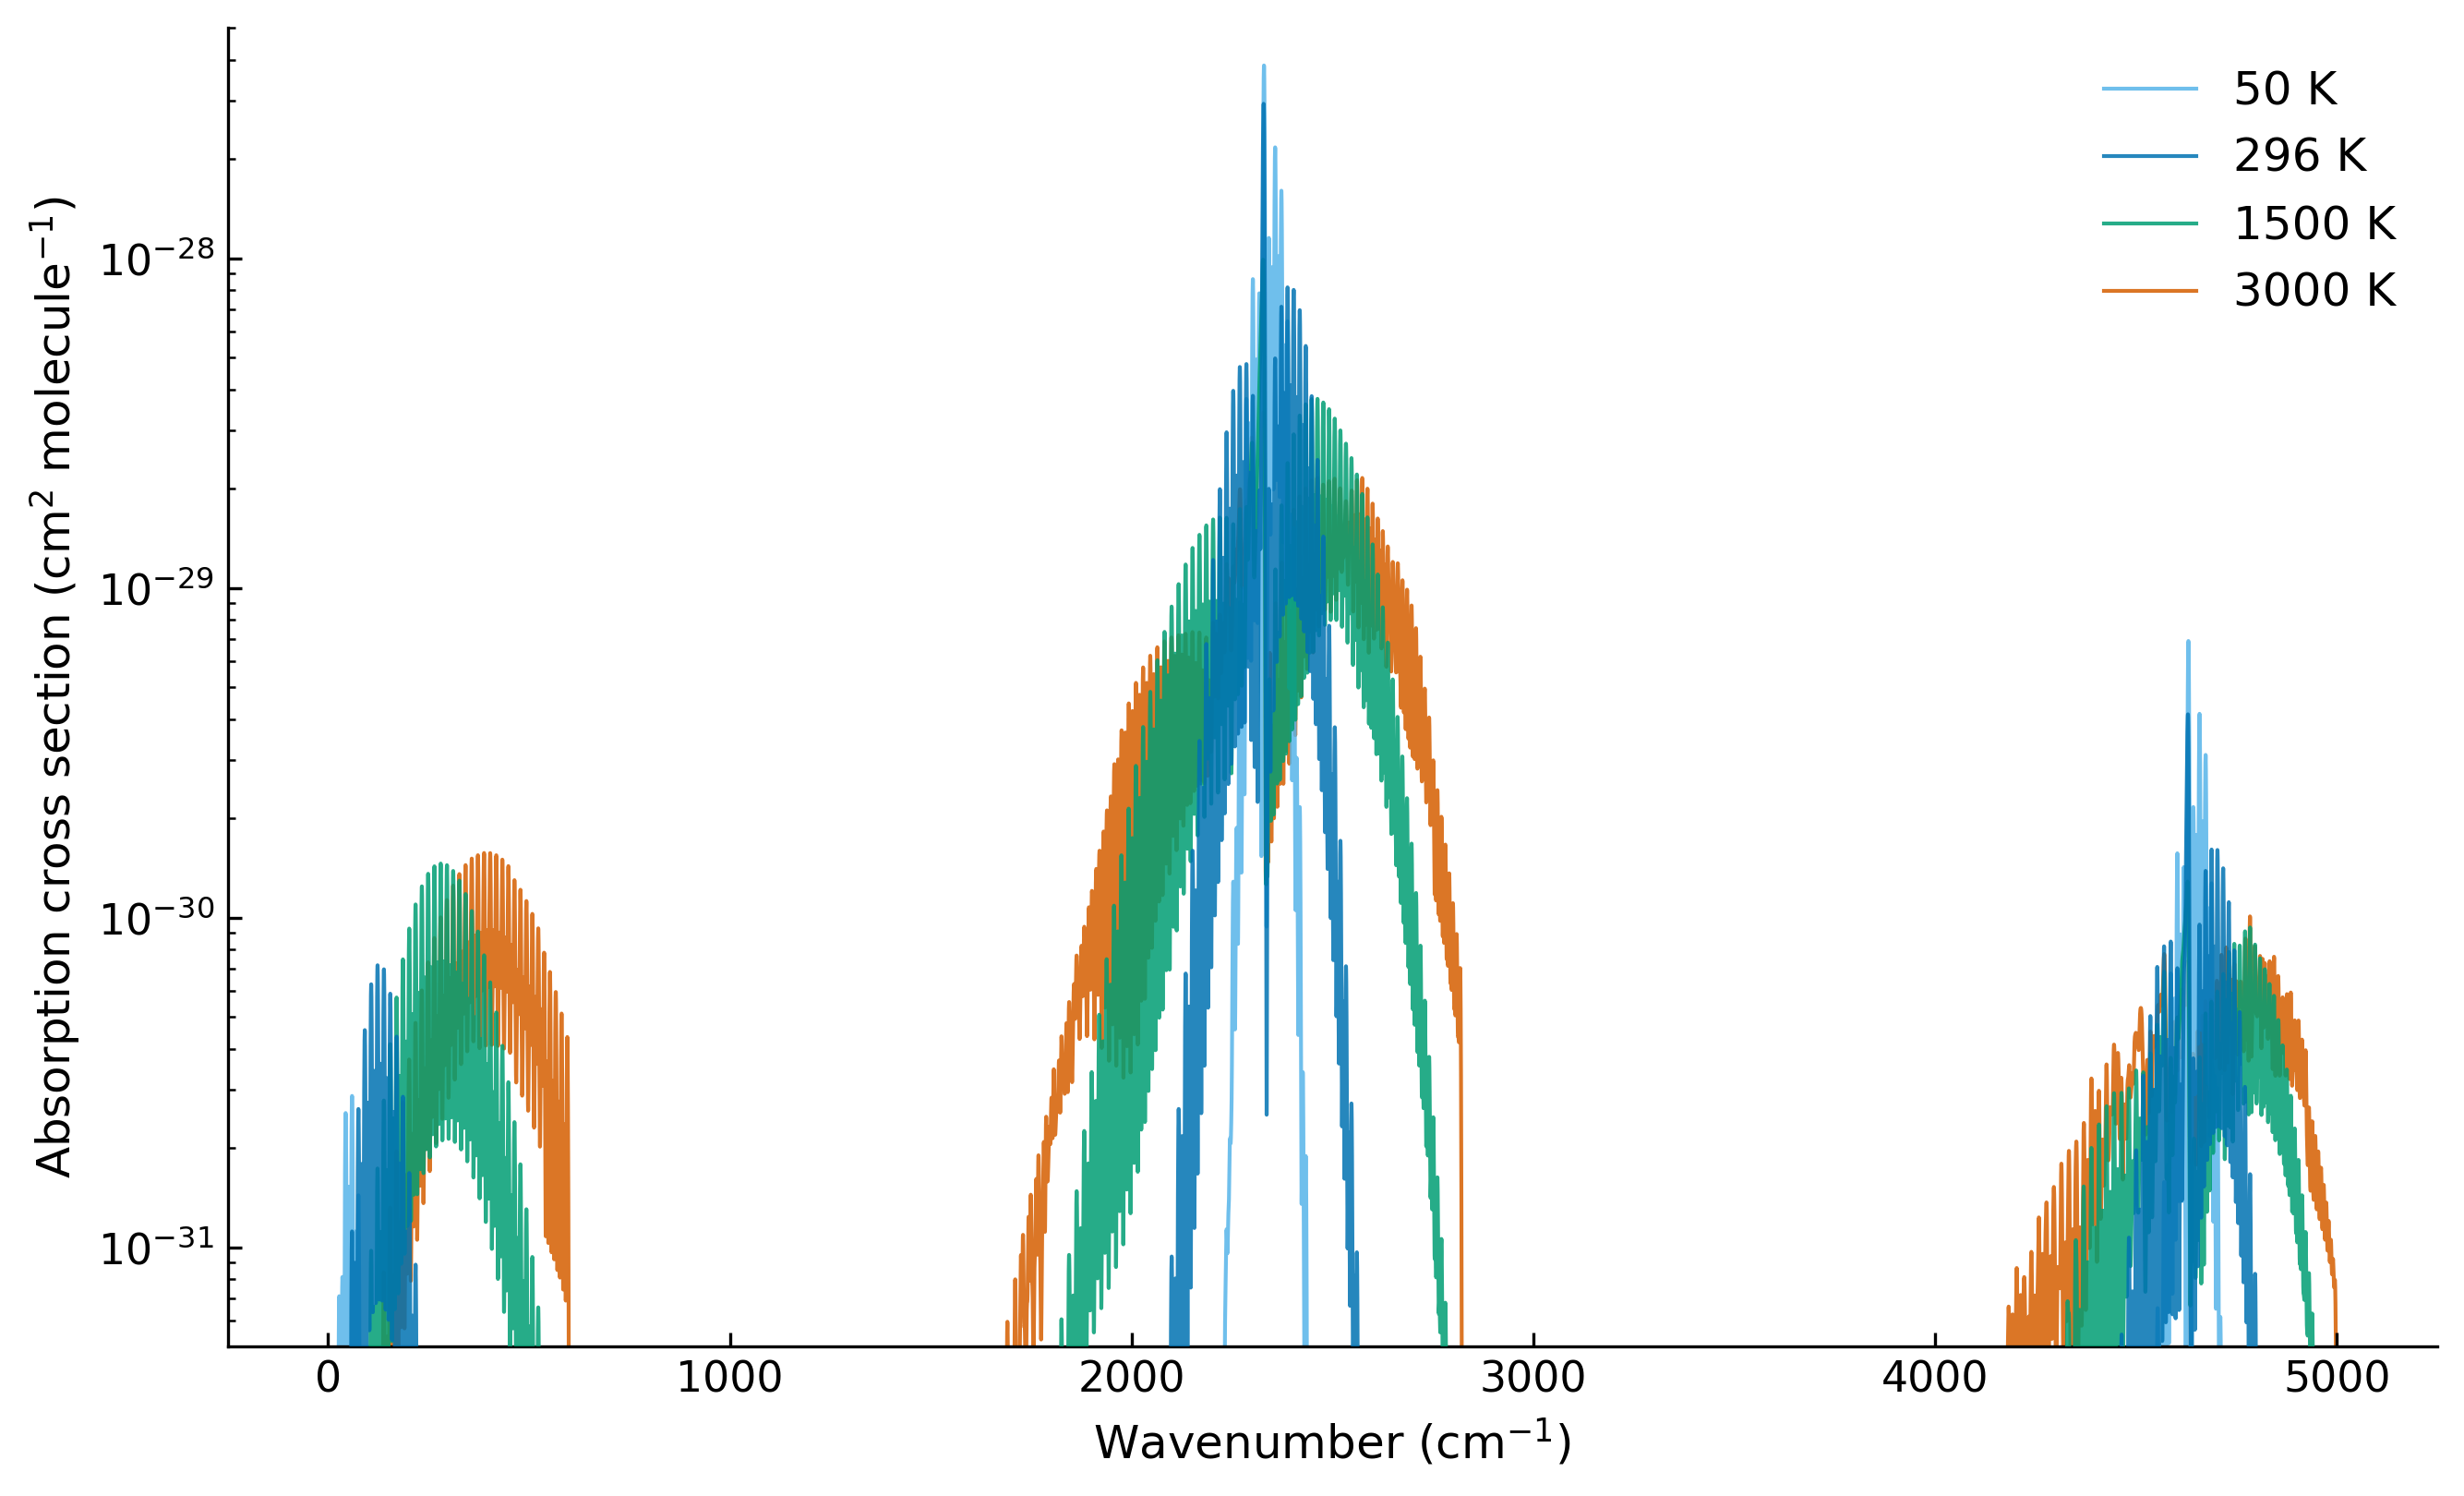

In [12]:
plt.figure(figsize=(9, 5.5), dpi=300)

# colourblind-safe, higher-contrast palette
c_50 = "#56B4E9"     # light blue
c_296 = "#0072B2"    # dark blue
c_1500 = "#009E73"   # green
c_3000 = "#D55E00"   # reddish orange

plt.plot(
    # N214_50K_gauss_wn, N214_50K_gauss_xsec,
    combined_50K_wn, combined_50K_xsec,
    color=c_50,
    linewidth=1,
    alpha=0.85,
    label="50 K",
    zorder=2
)

plt.plot(
    # N214_296K_gauss_wn, N214_296K_gauss_xsec,
    combined_296K_wn, combined_296K_xsec,
    color=c_296,
    linewidth=1,
    alpha=0.85,
    label="296 K",
    zorder=4
)

plt.plot(
    # N214_1500K_gauss_wn, N214_1500K_gauss_xsec,
    combined_1500K_wn, combined_1500K_xsec,
    color=c_1500,
    linewidth=1,
    alpha=0.85,
    label="1500 K",
    zorder=3
)

plt.plot(
    # N214_3000K_gauss_wn, N214_3000K_gauss_xsec,
    combined_3000K_wn, combined_3000K_xsec,
    color=c_3000,
    linewidth=1,
    alpha=0.85,
    label="3000 K",
    zorder=1
)

plt.yscale("log")

plt.xlabel(r"Wavenumber (cm$^{-1}$)", fontsize=12)
plt.ylabel(r"Absorption cross section (cm$^2$ molecule$^{-1}$)", fontsize=12)

plt.ylim(5e-32, 5e-28)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=11)

ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()


Simulated N$_2$ absorption cross sections on a logarithmic intensity scale up to 5000 cm$^{-1}$, including the pure rotational, fundamental, and first overtone bands. Contributions from all isotopologues are summed, and the spectra are Gaussian-broadened with HWHM = 2 cm$^{-1}$. Results are shown for 50, 296, 1500, and 3000 K, chosen to illustrate temperature regimes of astrophysical interest.

Apply heavy Gaussian broadening (at least 1 cm-1 HWHM) Add the different isotopologue signals on top of each other.

- protoplanetary disk: around 50K -> major cold volatile reservoir, N₂ ice/gas balance
- terrestrial atmosphere: 296K -> dominant component. 
- hot giant planet: around 1500K  -> N₂ predicted dominant nitrogen species
- hot brown dwarf/ ultrahot Jupiter: 3000K -> upper limit where N₂ may still persist

#### Zoomed in plot

- around small (around 10 wavenumber) region
- keep isotopologues separate - should show the spacing between lines
- only do two temperatures - 296K and 1500K
- broadening: can apply 0.1 cm (0.5 HWHM) Gaussian broadening. Then manually increase a bit the width of the higher temp line

In [13]:

N214_296K_zoomed_wn, N214_296K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/14N2_0_05_fund_296K.xsec")
N214_1500K_zoomed_wn, N214_1500K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/14N2_0_05_fund_1500K.xsec")
N214_3000K_zoomed_wn, N214_3000K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/14N2_0_05_fund_3000K.xsec")

N14N15_296K_zoomed_wn, N14N15_296K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/14N15N_0_05_fund_296K.xsec")
N14N15_1500K_zoomed_wn, N14N15_1500K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/14N15N_0_05_fund_1500K.xsec")
N14N15_3000K_zoomed_wn, N14N15_3000K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/14N15N_0_05_fund_3000K.xsec")

# N215_296K_zoomed_wn, N215_296K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/15N2_0_05_fund_296K.xsec")
# N215_3000K_zoomed_wn, N215_3000K_zoomed_xsec = load_xsec("ExoCross/cross_sections/fundamental_0_05/15N2_0_05_fund_3000K.xsec")



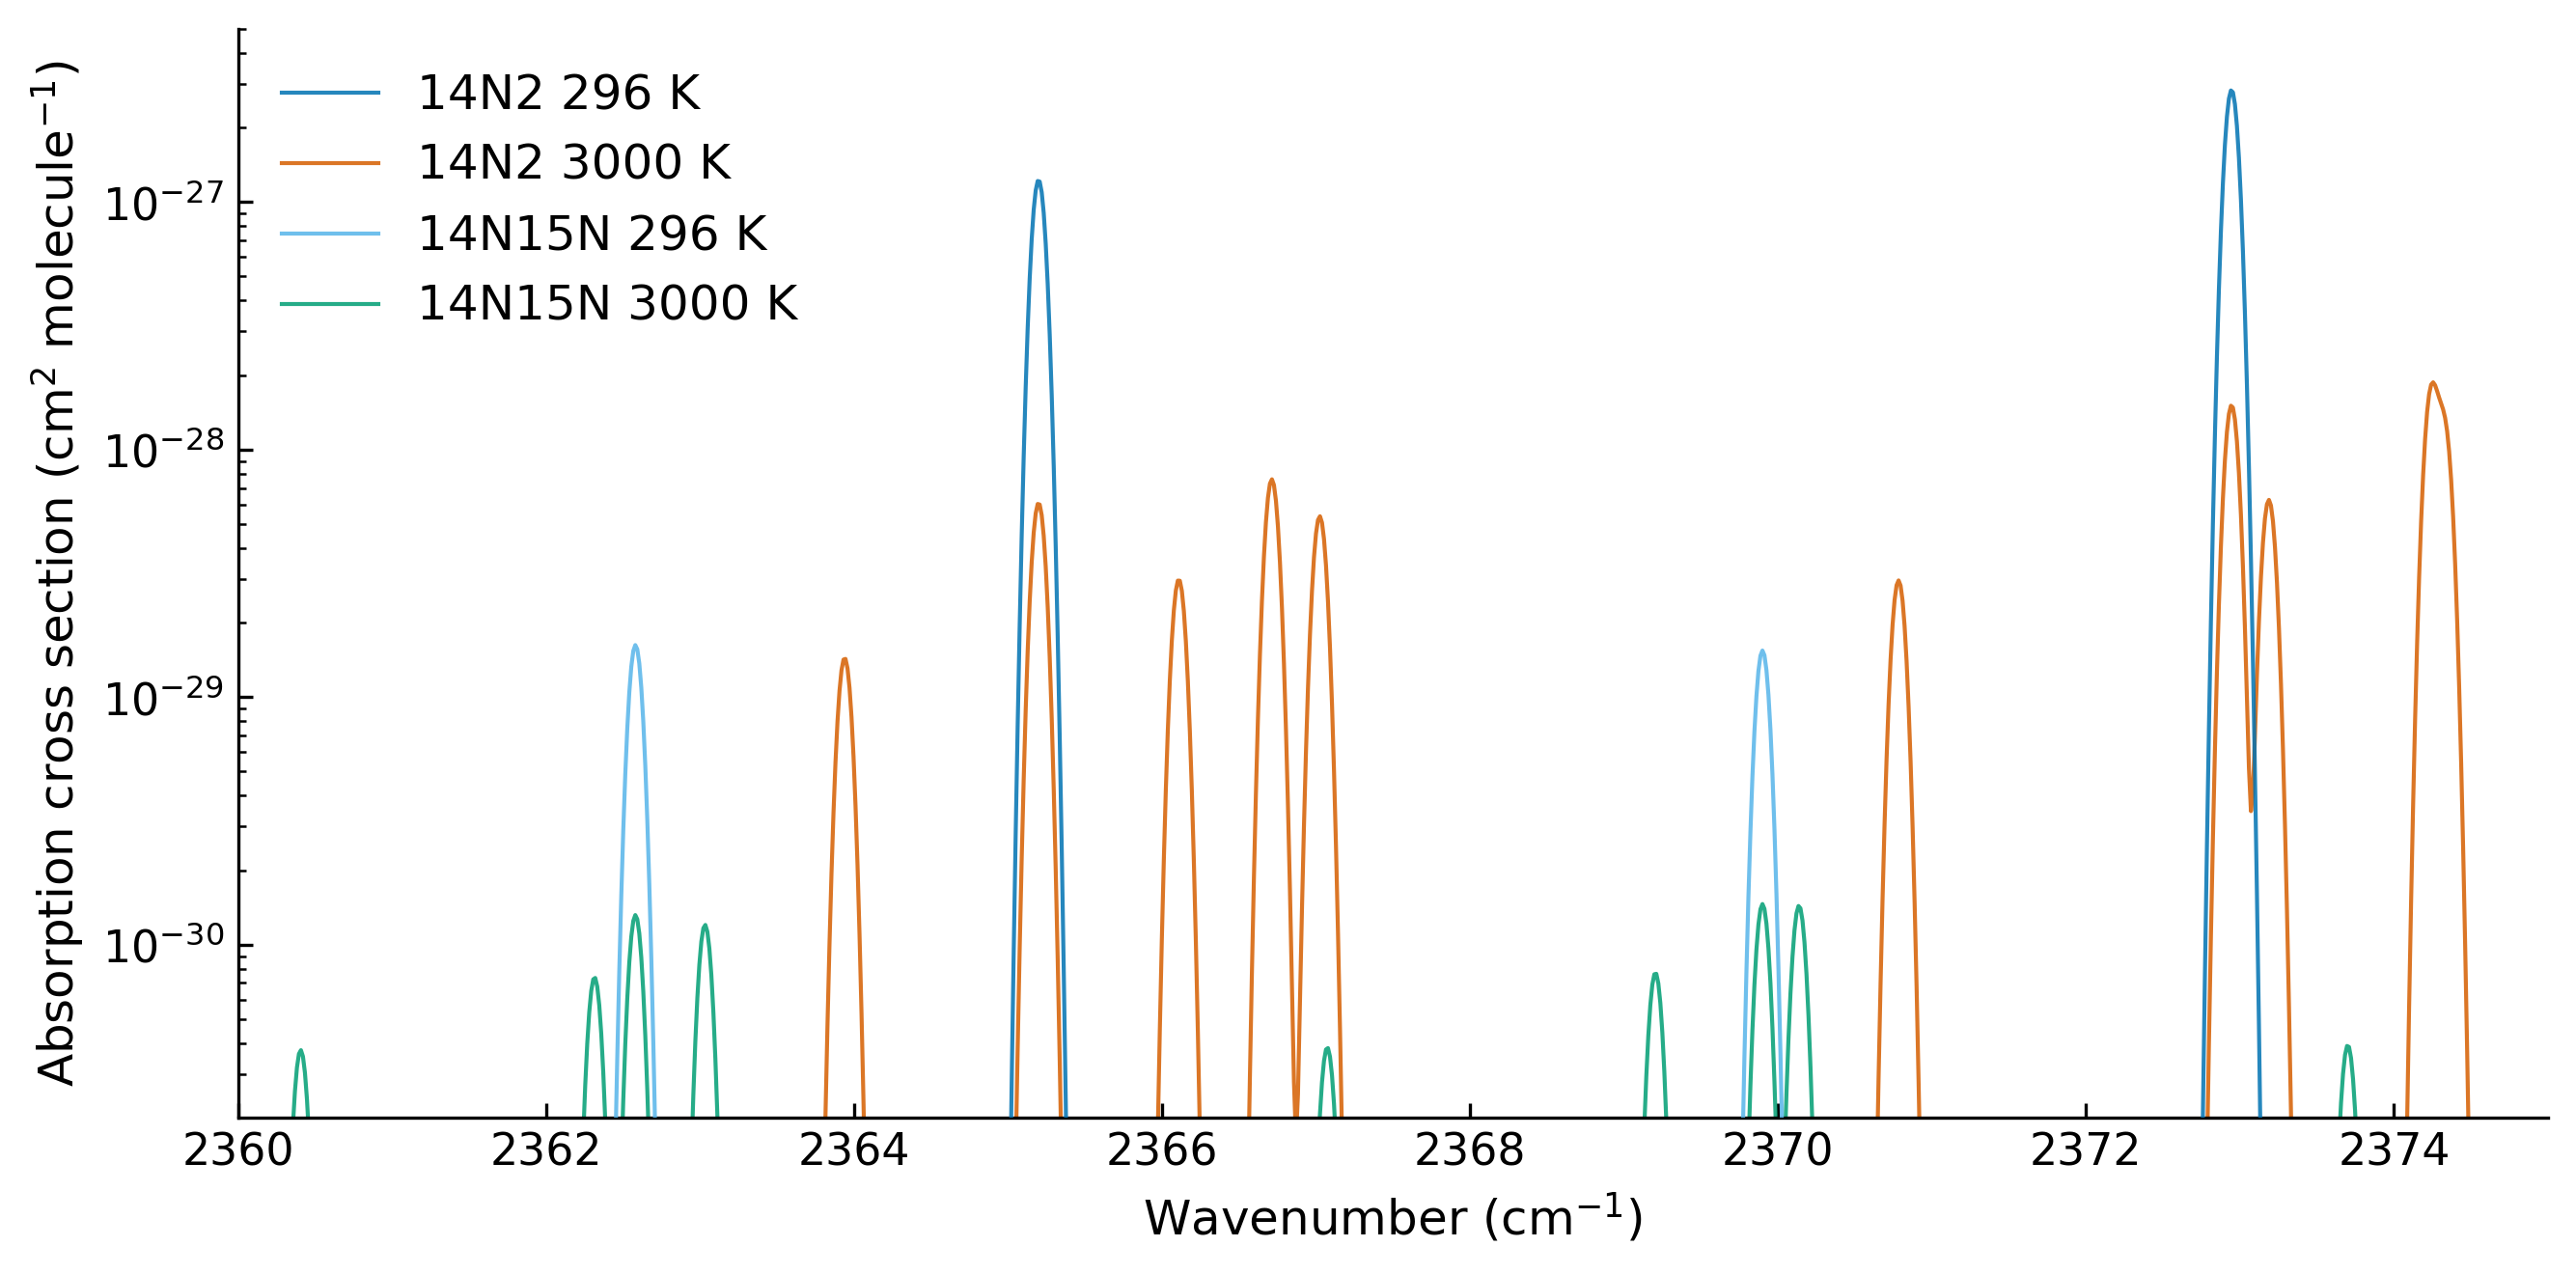

In [14]:

plt.figure(figsize=(9, 4.5), dpi=300)

# colourblind-safe, higher-contrast palette
c_296_14N2 = "#0072B2"    # dark blue
c_3000_14N2 = "#D55E00"   # reddish orange

plt.plot(
    # N214_296K_gauss_wn, N214_296K_gauss_xsec,
    N214_296K_zoomed_wn, N214_296K_zoomed_xsec,
    color=c_296_14N2,
    linewidth=1,
    alpha=0.85,
    label="14N2 296 K",
    zorder=4
)

plt.plot(
    N214_3000K_zoomed_wn, N214_3000K_zoomed_xsec,
    color=c_3000_14N2,
    linewidth=1,
    alpha=0.85,
    label="14N2 3000 K",
    zorder=1
)


# now plot the zoomed cross sections for 14N15N and 15N2 on top, with lighter colours
c_296_14N15N = "#56B4E9"    # light blue
c_3000_14N15N = "#009E73"   # green

plt.plot(
    N14N15_296K_zoomed_wn, N14N15_296K_zoomed_xsec,
    color=c_296_14N15N,
    linewidth=1,
    alpha=0.85,
    label="14N15N 296 K",
    zorder=3
)


plt.plot(
    N14N15_3000K_zoomed_wn, N14N15_3000K_zoomed_xsec,
    color=c_3000_14N15N,
    linewidth=1,
    alpha=0.85,
    label="14N15N 3000 K",
    zorder=2
)


plt.yscale("log")

plt.xlabel(r"Wavenumber (cm$^{-1}$)", fontsize=12)
plt.ylabel(r"Absorption cross section (cm$^2$ molecule$^{-1}$)", fontsize=12)

plt.ylim(5e-29, 1e-26)
plt.ylim(2e-31, 5e-27)
plt.xlim(2900, 2320)
plt.xlim(1600, 2900)

# 14N15N stronger, weak 1500K
plt.xlim(2305, 2320)

plt.xlim(1600, 2900)
plt.xlim(2360, 2380)
plt.xlim(2360, 2375)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=11)

ax.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()


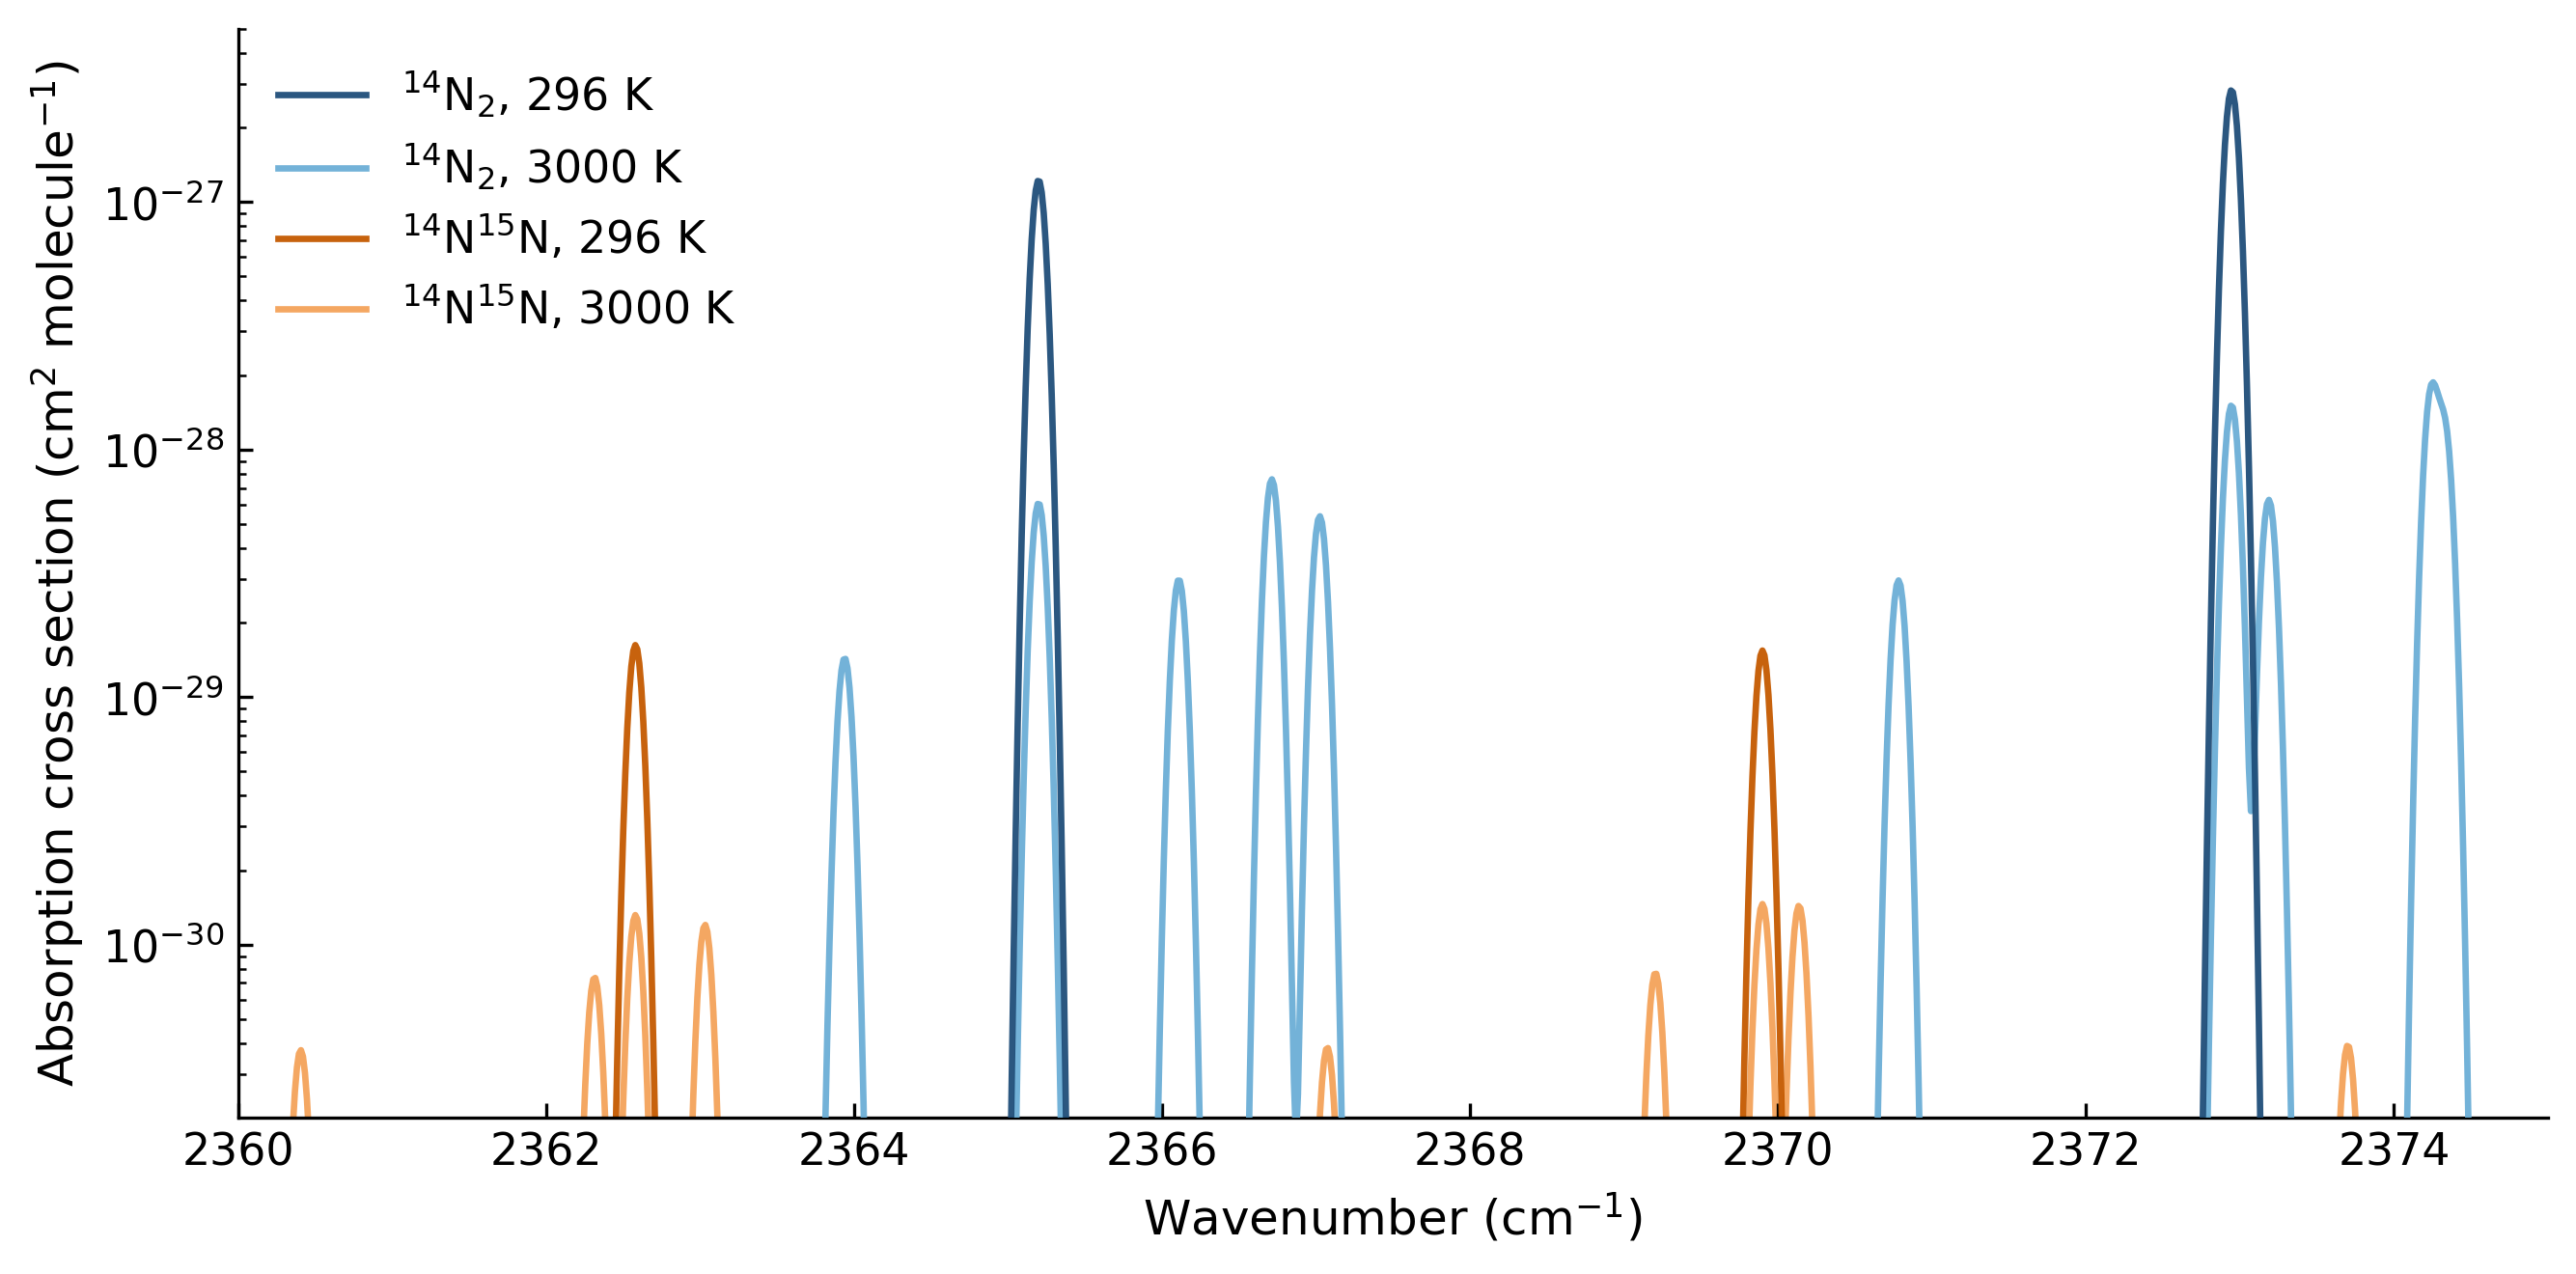

In [15]:
plt.figure(figsize=(9, 4.5), dpi=300)

# blue family for 14N2
c_14N2_296 = "#1f4e79"   # deep blue
c_14N2_3000 = "#6baed6"  # lighter blue

# orange family for 14N15N
c_14N15N_296 = "#c45a00"   # deep orange
c_14N15N_3000 = "#f4a259"  # lighter orange

plt.plot(
    N214_296K_zoomed_wn, N214_296K_zoomed_xsec,
    color=c_14N2_296,
    linewidth=1.6,
    alpha=0.95,
    label=r"$^{14}$N$_2$, 296 K",
    zorder=4
)

plt.plot(
    N214_3000K_zoomed_wn, N214_3000K_zoomed_xsec,
    color=c_14N2_3000,
    linewidth=1.6,
    alpha=0.95,
    label=r"$^{14}$N$_2$, 3000 K",
    zorder=3
)

plt.plot(
    N14N15_296K_zoomed_wn, N14N15_296K_zoomed_xsec,
    color=c_14N15N_296,
    linewidth=1.6,
    alpha=0.95,
    label=r"$^{14}$N$^{15}$N, 296 K",
    zorder=2
)

plt.plot(
    N14N15_3000K_zoomed_wn, N14N15_3000K_zoomed_xsec,
    color=c_14N15N_3000,
    linewidth=1.6,
    alpha=0.95,
    label=r"$^{14}$N$^{15}$N, 3000 K",
    zorder=1
)

plt.yscale("log")

plt.xlabel(r"Wavenumber (cm$^{-1}$)", fontsize=12)
plt.ylabel(r"Absorption cross section (cm$^2$ molecule$^{-1}$)", fontsize=12)

plt.ylim(2e-31, 5e-27)
plt.xlim(2360, 2375)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=11)

ax.legend(frameon=False, fontsize=11, loc="upper left")

plt.tight_layout()
plt.show()


Simulated absorption cross sections for $^{14}$N$_2$ and $^{14}$N$^{15}$N in the 2360-2375 cm$^{-1}$ region (within fundamental band), shown on a logarithmic scale for 296 and 3000 K. The spectra were Gaussian-broadened with HWHM = 0.5 cm$^{-1}$, with Doppler broadening neglected.


### Partition functions

Sources:
- HITRAN: https://hitran.iao.ru/partfun/index/mol/022
- ESA: ESA_STR246_revised

In [16]:

HITRAN_14N2_partfunc_file = np.loadtxt("HITRAN/partition_functions/Partfun_14N14N.txt", comments="#")
t_HITRAN_14N2 = HITRAN_14N2_partfunc_file[:, 0]
q_HITRAN_14N2 = HITRAN_14N2_partfunc_file[:, 1]
HITRAN_14N15N_partfunc_file = np.loadtxt("HITRAN/partition_functions/Partfun_14N15N.txt", comments="#")
t_HITRAN_14N15N = HITRAN_14N15N_partfunc_file[:, 0]
q_HITRAN_14N15N = HITRAN_14N15N_partfunc_file[:, 1]

t_ESA = np.array([1.00000e-05, 1.00000e-04, 1.00000e-03, 1.00000e-02, 1.00000e-01, 1.50000e-01, 2.00000e-01, 3.00000e-01, 5.00000e-01, 7.00000e-01, 1.00000e+00, 1.30000e+00, 1.70000e+00, 2.00000e+00, 3.00000e+00, 5.00000e+00, 7.00000e+00, 1.00000e+01, 1.50000e+01, 2.00000e+01, 3.00000e+01, 5.00000e+01, 7.00000e+01, 1.00000e+02, 1.30000e+02, 1.70000e+02, 2.00000e+02, 2.50000e+02, 3.00000e+02, 5.00000e+02, 7.00000e+02, 1.00000e+03, 1.50000e+03, 2.00000e+03, 3.00000e+03, 4.00000e+03, 5.00000e+03, 6.00000e+03, 7.00000e+03, 8.00000e+03, 9.00000e+03, 1.00000e+04])

q_ESA = np.array([6.66667e-01, 6.66667e-01, 6.66667e-01, 6.66667e-01, 6.66667e-01, 6.66667e-01, 6.66667e-01, 6.66667e-01, 6.66677e-01, 6.66947e-01, 6.69930e-01, 6.78902e-01, 7.01273e-01, 7.24412e-01, 8.25894e-01, 1.09479e+00, 1.41362e+00, 1.92468e+00, 2.79343e+00, 3.66511e+00, 5.41032e+00, 8.90297e+00, 1.23967e+01, 1.76381e+01, 2.28805e+01, 2.98713e+01, 3.51153e+01, 4.38567e+01, 5.26005e+01, 8.76988e+01, 1.23648e+02, 1.81616e+02, 2.94922e+02, 4.33091e+02, 7.89979e+02, 1.25849e+03, 1.84233e+03, 2.54515e+03, 3.37135e+03, 4.32734e+03, 5.42405e+03, 6.68047e+03])

exocross_14N2_partfunc_file = np.loadtxt("ExoCross/partition_functions/14N2_partfunc.pf")
exocross_14N15N_partfunc_file = np.loadtxt("ExoCross/partition_functions/14N15N_partfunc.pf")
exocross_15N2_partfunc_file = np.loadtxt("ExoCross/partition_functions/15N2_partfunc.pf")

t_exocross_14N2 = exocross_14N2_partfunc_file[:, 0]
q_exocross_14N2 = exocross_14N2_partfunc_file[:, 1]
t_exocross_14N15N = exocross_14N15N_partfunc_file[:, 0]
q_exocross_14N15N = exocross_14N15N_partfunc_file[:, 1]
t_exocross_15N2 = exocross_15N2_partfunc_file[:, 0]
q_exocross_15N2 = exocross_15N2_partfunc_file[:, 1]

q_ESA_scaled = q_ESA * 9

#### Plots

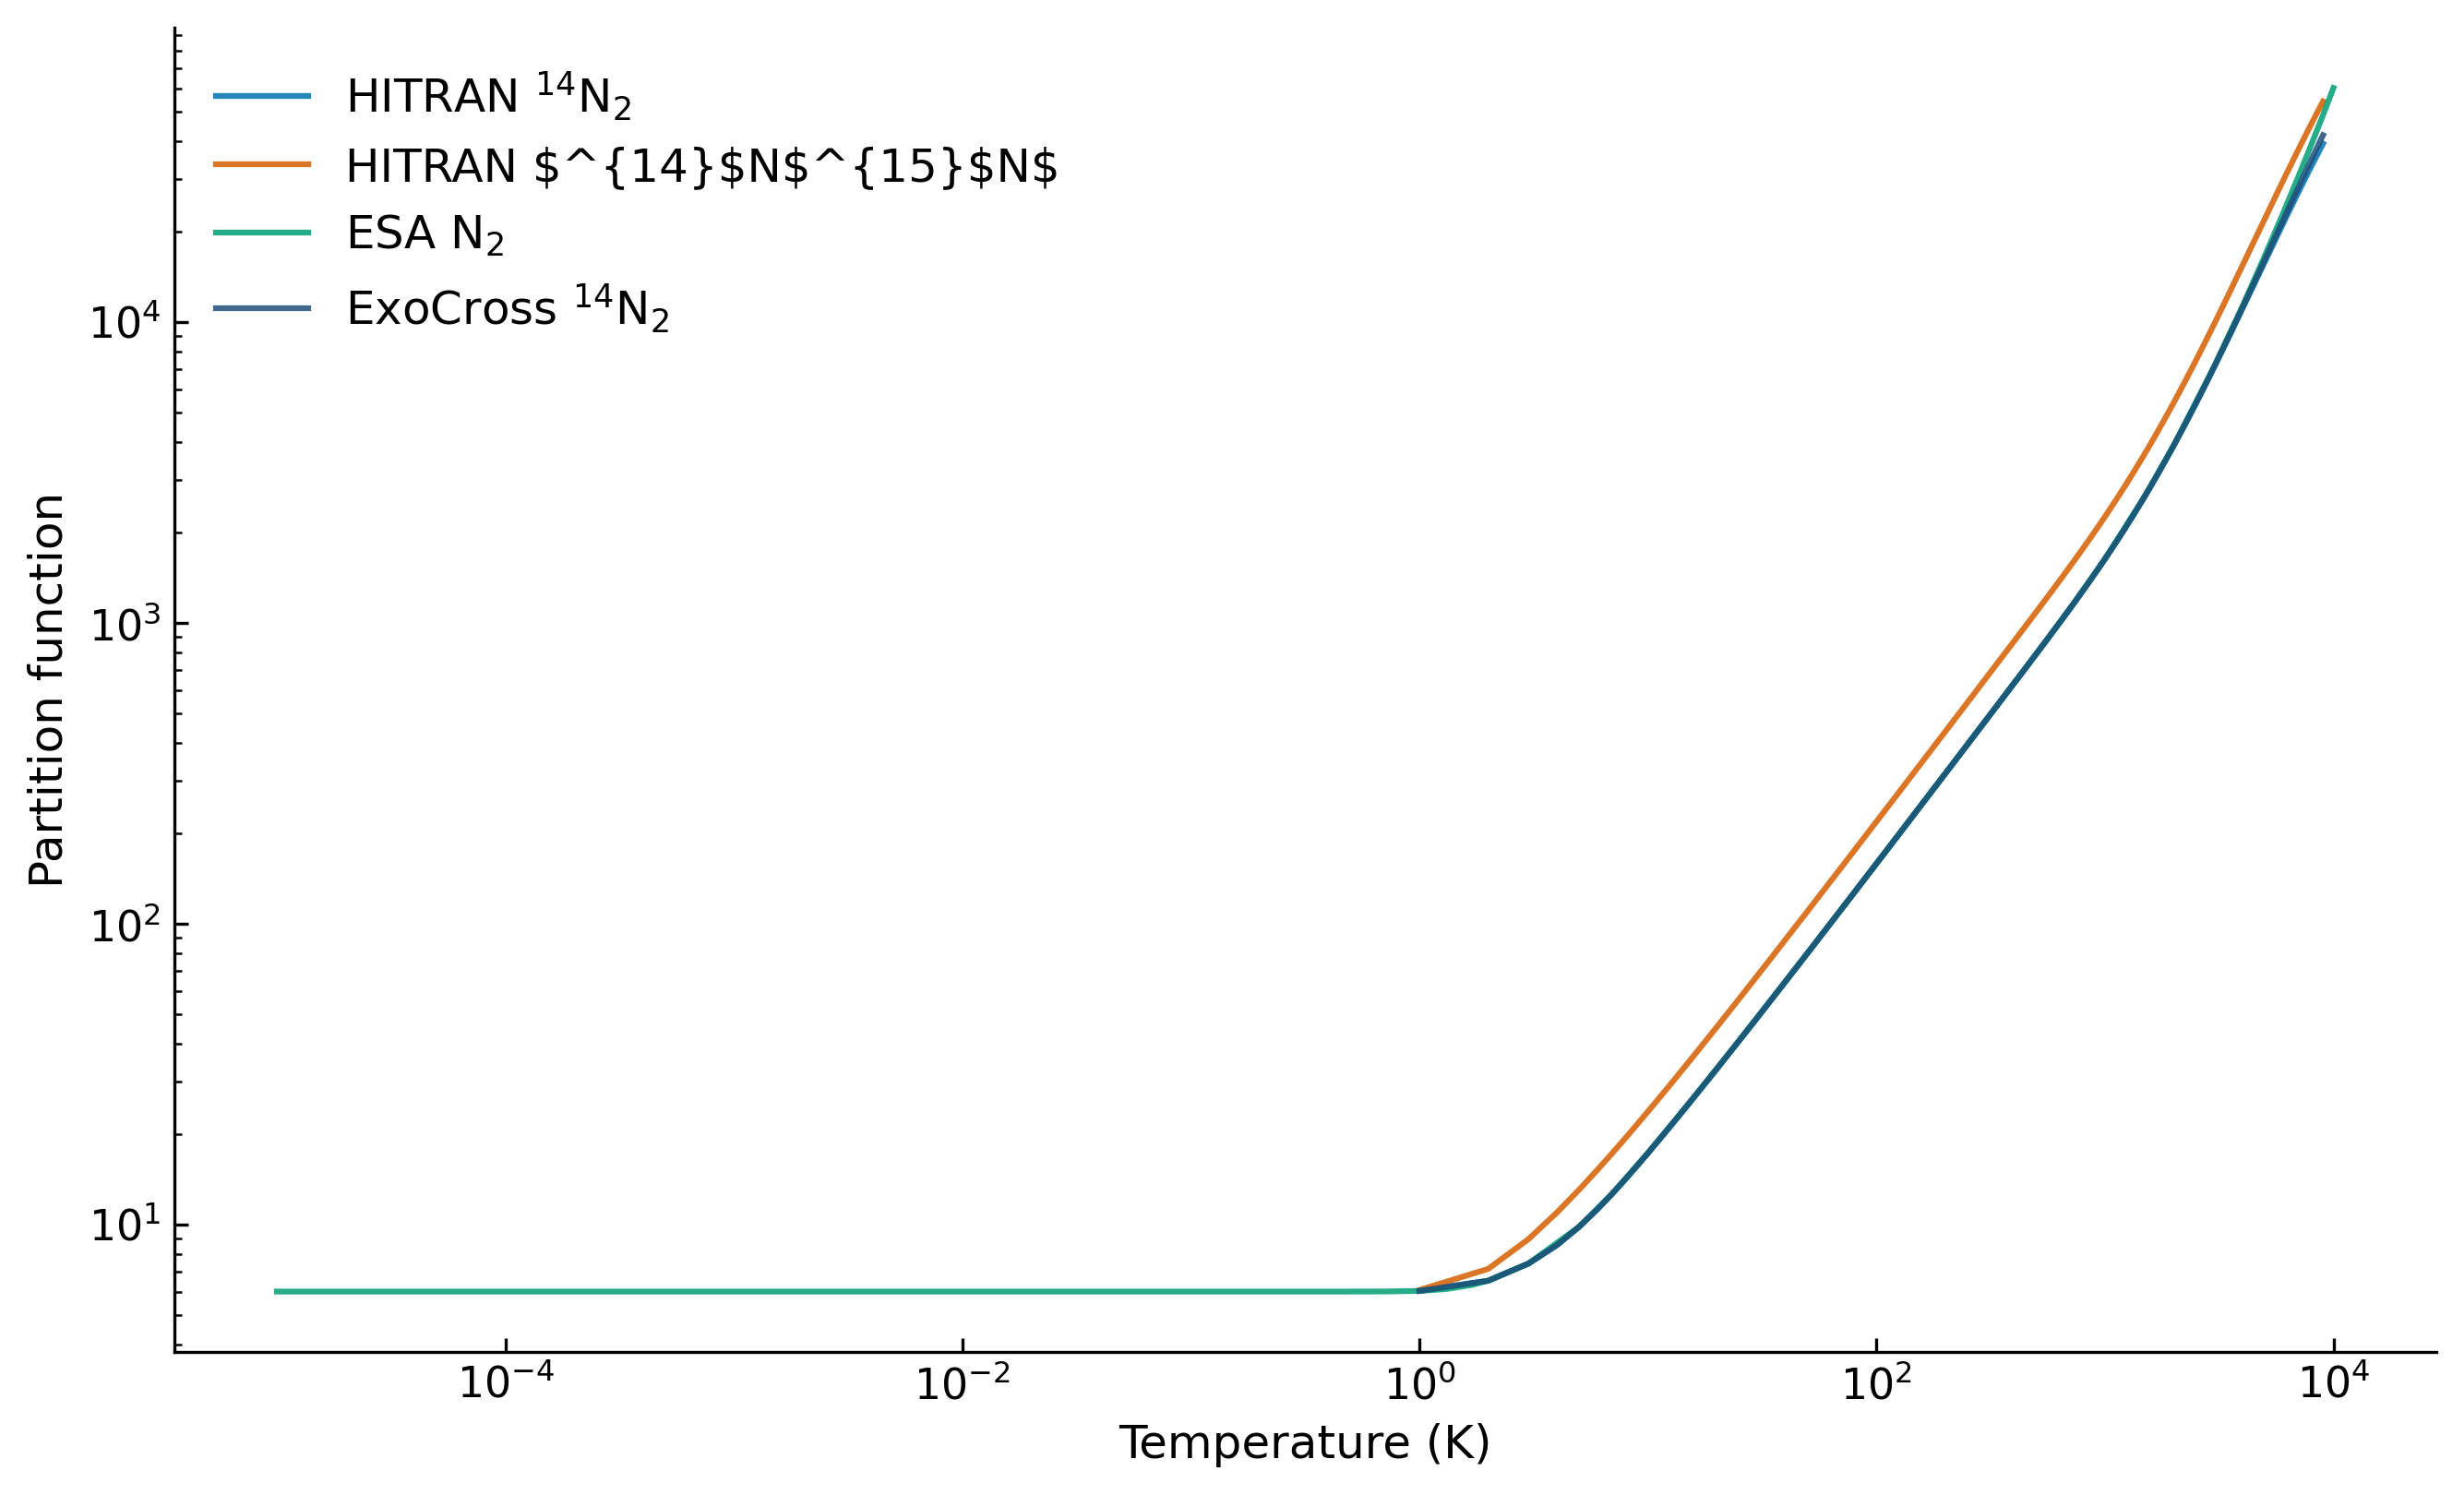

In [17]:
# plot the partition functions on a log-log plot
plt.figure(figsize=(9, 5.5), dpi=300)
plt.plot(
    t_HITRAN_14N2, q_HITRAN_14N2,
    color="#0072B2",
    linewidth=1.5,
    alpha=0.85,
    label=r"HITRAN $^{14}$N$_2$"
)
plt.plot(
    t_HITRAN_14N15N, q_HITRAN_14N15N,
    color="#D55E00",
    linewidth=1.5,
    alpha=0.85,
    label=r"HITRAN $^{14}$N$^{15}$N$"
)

plt.plot(
    t_ESA, q_ESA_scaled,
    color="#009E73",
    linewidth=1.5,
    alpha=0.85,
    label="ESA N$_2$"
)  

plt.plot(
    t_exocross_14N2, q_exocross_14N2,
    color="#1f4e79",
    linewidth=1.5,
    alpha=0.85,
    label=r"ExoCross $^{14}$N$_2$"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Temperature (K)", fontsize=12)
plt.ylabel("Partition function", fontsize=12)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=11)
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2033569/3569143821.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


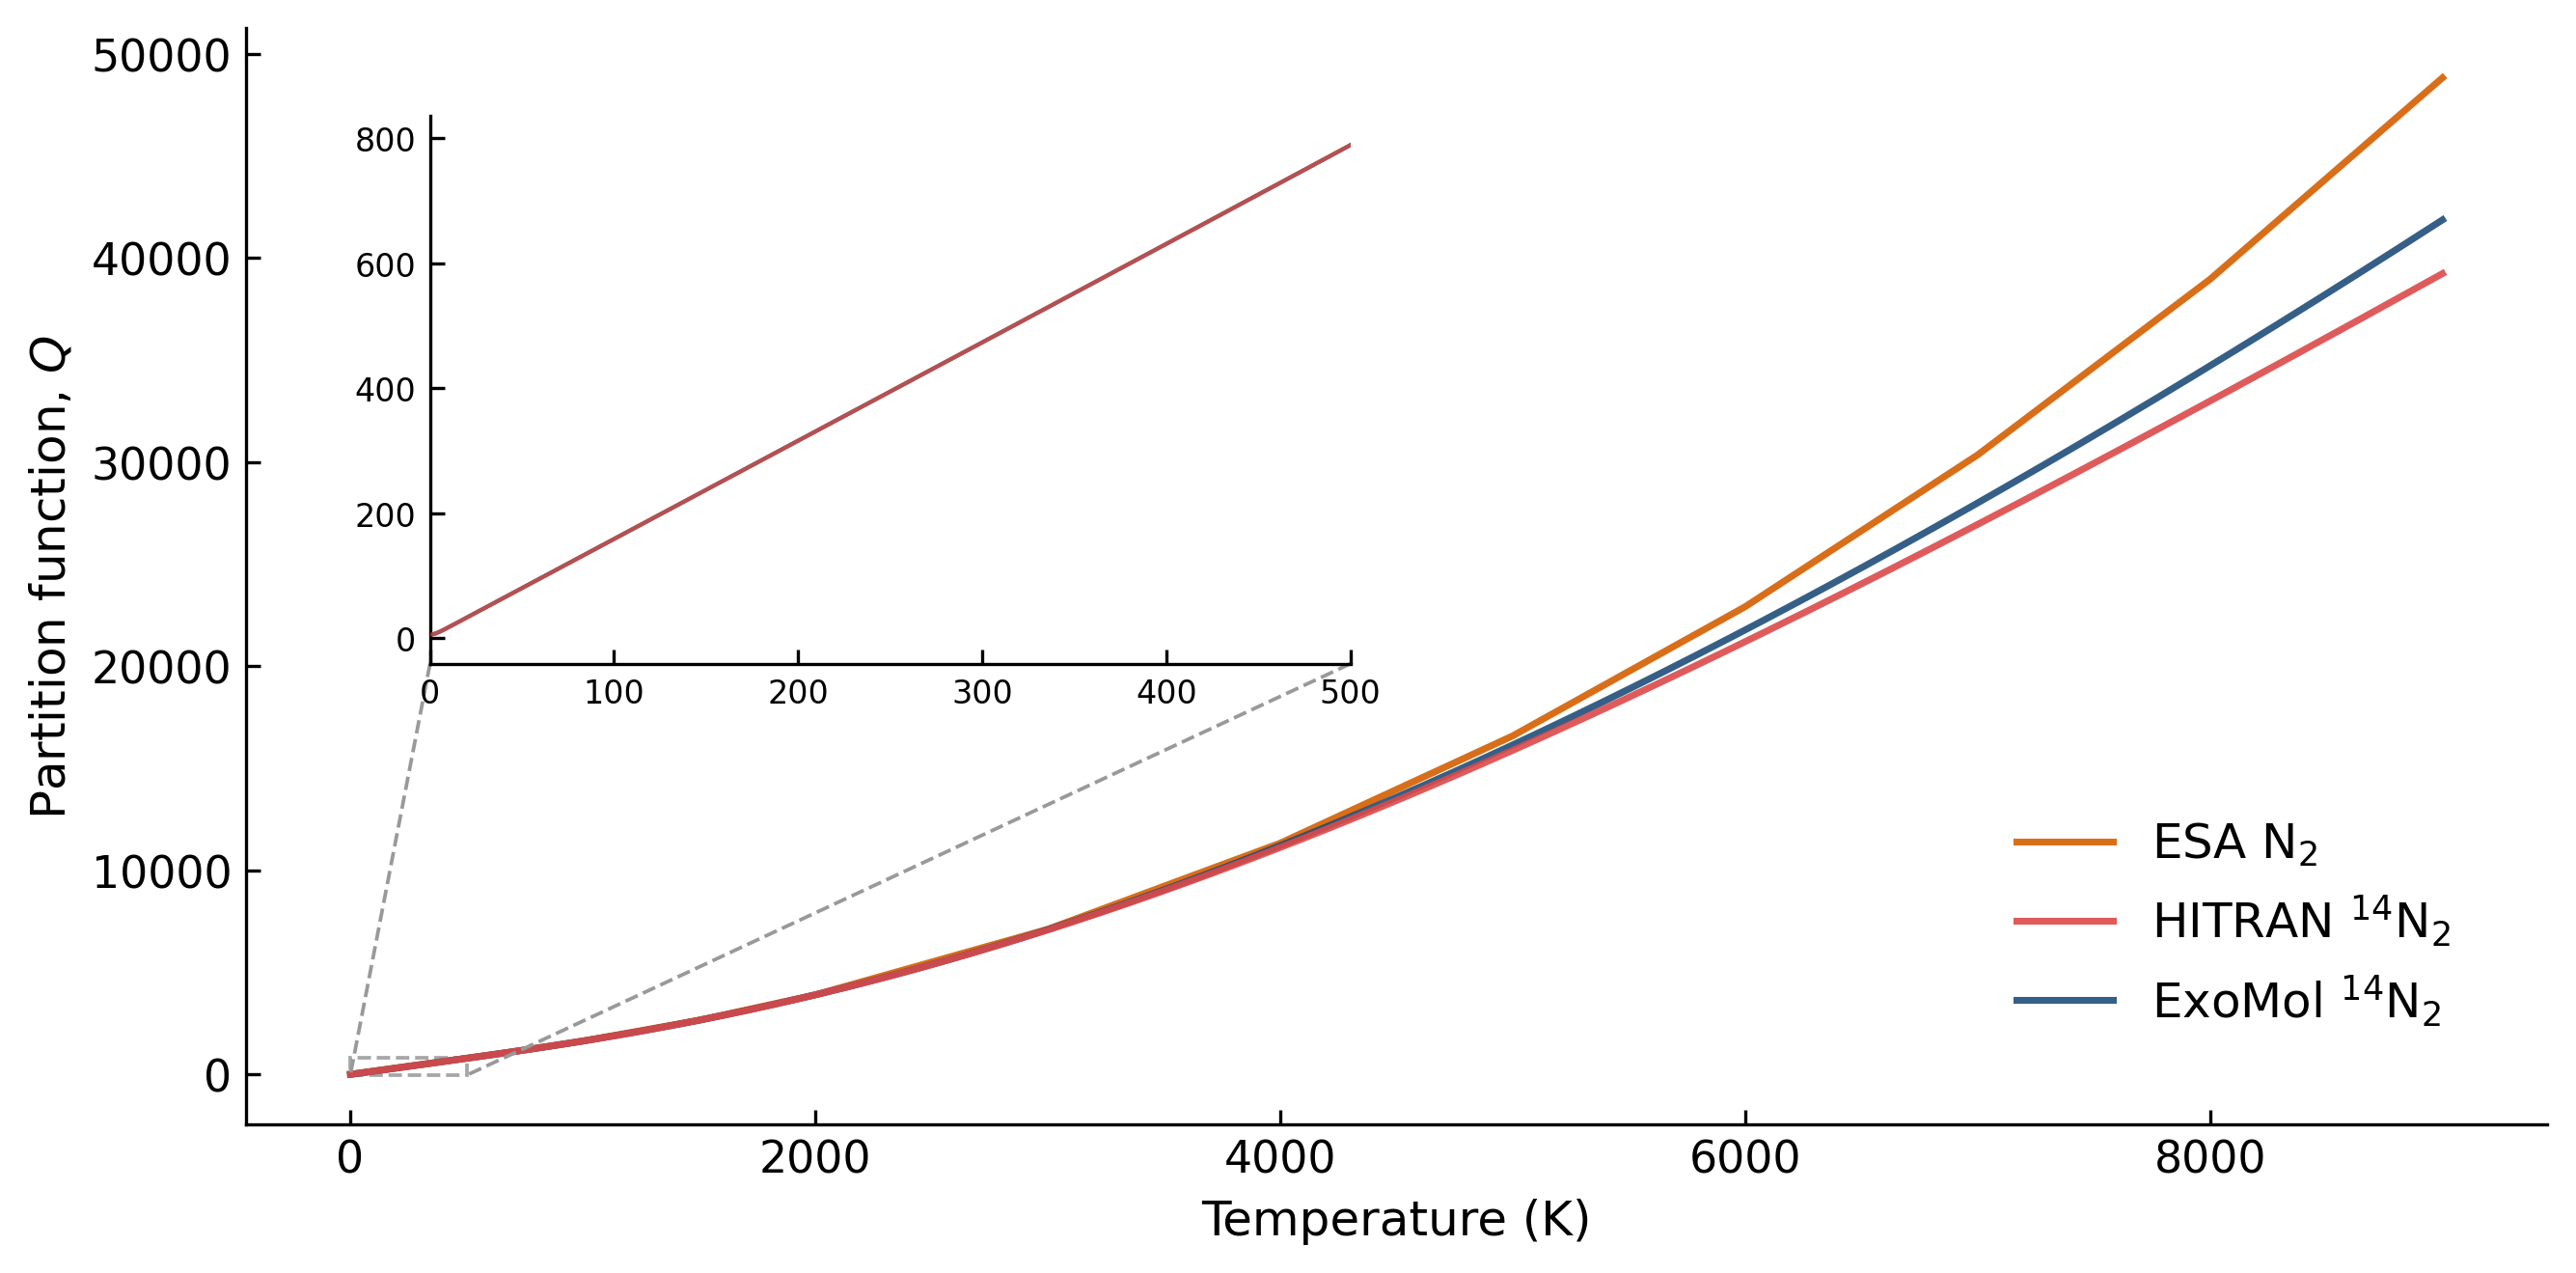

In [18]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
# plot partition functions: HITRAN 14N2 and ESA only, starting from 1 K

esa_mask = (t_ESA >= 1) & (t_ESA <= 9000)

plt.figure(figsize=(9, 4.5), dpi=300)
ax = plt.gca()

# main plot
ax.plot(
    t_ESA[esa_mask], q_ESA_scaled[esa_mask],
    color="#D55E00",
    linewidth=1.7,
    alpha=0.9,
    label="ESA N$_2$",
    zorder=1
)

ax.plot(
    t_HITRAN_14N2, q_HITRAN_14N2,
    color="#DC4949",
    linewidth=1.7,
    alpha=0.9,
    label=r"HITRAN $^{14}$N$_2$",
    zorder=3
)

ax.plot(
    t_exocross_14N2, q_exocross_14N2,
    color="#1f4e79",
    linewidth=1.7,
    alpha=0.9,
    label=r"ExoMol $^{14}$N$_2$",
    zorder=2
)

# other isotopologues
# ax.plot(
#     t_HITRAN_14N15N, q_HITRAN_14N15N,
#     color="#DC4949",
#     linewidth=1.0,
#     alpha=0.5,
#     label=r"HITRAN $^{14}$N$^{15}$N$",
#     zorder=4  
# )

# ax.plot(
#     t_exocross_14N15N, q_exocross_14N15N,
#     color="#1f4e79",
#     linewidth=1.0,
#     alpha=0.5,
#     label=r"ExoMol $^{14}$N$^{15}$N$",
#     zorder=5
# )

ax.set_xlabel("Temperature (K)", fontsize=12)
ax.set_ylabel("Partition function, $Q$", fontsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=11)

ax.legend(frameon=False, fontsize=12, loc="lower right", borderpad=1.5)

# -------------------------
# inset: 50-350 K region
# -------------------------
# axins = inset_axes(ax, width="34%", height="42%", loc="upper left", borderpad=3.3)

axins = inset_axes(
    ax,
    width="40%",
    height="50%",
    loc="upper left",
    bbox_to_anchor=(0.08, -0.08, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)


inset_lower_val = 0
inset_upper_val = 500

esa_zoom_mask = (t_ESA >= inset_lower_val) & (t_ESA <= inset_upper_val)
hitran_zoom_mask = (t_HITRAN_14N2 >= inset_lower_val) & (t_HITRAN_14N2 <= inset_upper_val)
exocross_zoom_mask = (t_exocross_14N2 >= inset_lower_val) & (t_exocross_14N2 <= inset_upper_val)

axins.plot(
    t_ESA[esa_zoom_mask], q_ESA_scaled[esa_zoom_mask],
    color="#D55E00",
    linewidth=1,
    alpha=0.7,
    zorder=1
)

axins.plot(
    t_HITRAN_14N2[hitran_zoom_mask], q_HITRAN_14N2[hitran_zoom_mask],
    color="#DC4949",
    linewidth=1,
    alpha=0.7,
    zorder=3
)

axins.plot(
    t_exocross_14N2[exocross_zoom_mask], q_exocross_14N2[exocross_zoom_mask],
    color="#1f4e79",
    linewidth=1,
    alpha=0.7,
    zorder=2
)

axins.set_xlim(inset_lower_val, inset_upper_val)

# let matplotlib choose the y-range from the data, but add a small margin
ymin = min(
    q_ESA_scaled[esa_zoom_mask].min(),
    q_HITRAN_14N2[hitran_zoom_mask].min(),
    q_exocross_14N2[exocross_zoom_mask].min()
)
ymax = max(
    q_ESA_scaled[esa_zoom_mask].max(),
    q_HITRAN_14N2[hitran_zoom_mask].max(),
    q_exocross_14N2[exocross_zoom_mask].max()
)

pad = 0.06 * (ymax - ymin)
axins.set_ylim(ymin - pad, ymax + pad)

axins.spines["top"].set_visible(False)
axins.spines["right"].set_visible(False)
axins.tick_params(axis="both", which="both", direction="in", labelsize=8)
# axins.set_title(f"{inset_lower_val}-{inset_upper_val} K", fontsize=10, pad=2)

# ax.set_yscale("log")

plt.tight_layout()

pp, p1, p2 = mark_inset(
    ax, axins,
    loc1=3, loc2=4,   # bottom corners only
    fc="none",
    ec="0.6",
    lw=0.9,
    ls="--"
)

# make the zoom rectangle a little lighter than the connector lines
pp.set_edgecolor("0.65")
pp.set_linestyle("--")
pp.set_linewidth(0.9)

plt.show()


Comparison of the $^{14}$N$_2$ partition function, $Q$, from ESA, HITRAN, and ExoMol over 1-9000 K; the ESA values have been scaled as described in the text. The inset shows the low-temperature region from 1 to 500 K.

In [19]:
print(f"At 50 K: ExoCross is {q_exocross_14N2[50]:.1f} and HITRAN is {q_HITRAN_14N2[50]:.1f}, so ExoCross is {(1 - q_exocross_14N2[50] / q_HITRAN_14N2[50]) * 100:.5}% lower than HITRAN.")
print(f"At 296 K: ExoCross is {q_exocross_14N2[295]:.1f} and HITRAN is {q_HITRAN_14N2[295]:.1f}, so ExoCross is {(1 - q_exocross_14N2[295] / q_HITRAN_14N2[295]) * 100:.5f}% lower than HITRAN.")
print(f"At 1500 K: ExoCross is {q_exocross_14N2[1500]:.1f} and HITRAN is {q_HITRAN_14N2[1500]:.1f}, so ExoCross is {(1 - q_exocross_14N2[1500] / q_HITRAN_14N2[1500]) * 100:.5f}% lower than HITRAN.")
print(f"At 3000 K: ExoCross is {q_exocross_14N2[3000]:.1f} and HITRAN is {q_HITRAN_14N2[3000]:.1f}, so ExoCross is {(1 - q_exocross_14N2[3000] / q_HITRAN_14N2[3000]) * 100:.5f}% lower than HITRAN.")  

print(f"At 296K: ExoCross 14N15N is {q_exocross_14N15N[295]:.1f} and HITRAN is {q_HITRAN_14N15N[295]:.1f}, so ExoCross is {(1 - q_exocross_14N15N[295] / q_HITRAN_14N15N[295]) * 100:.5f}% lower than HITRAN.")


At 50 K: ExoCross is 81.7 and HITRAN is 81.7, so ExoCross is 0.0% lower than HITRAN.
At 296 K: ExoCross is 467.1 and HITRAN is 467.1, so ExoCross is 0.00015% lower than HITRAN.
At 1500 K: ExoCross is 2656.5 and HITRAN is 2656.5, so ExoCross is -0.00060% lower than HITRAN.
At 3000 K: ExoCross is 7097.4 and HITRAN is 7079.2, so ExoCross is -0.25608% lower than HITRAN.
At 296K: ExoCross 14N15N is 644.1 and HITRAN is 644.1, so ExoCross is -0.00028% lower than HITRAN.
